# Task 1 : Robot Navigation Environment with Pygame
## Step 1: Import Dependencies and Define Parameters
## Step 2: Define Core Functions
new_episode: Initializes robot and target positions
clip: Keeps values within a defined range (currently unused)
update_pose: Calculates the new robot pose based on wheel velocities


Below we import the necessary libraries and define all functions required to run in part 1. Extra tips provided has been commented out but also be implemented.

In [1289]:
import pygame
import random
import math
import time

# Initialise Pygame
pygame.init()


WIDTH, HEIGHT = 800, 600
FIELD = pygame.Rect(50, 50, WIDTH-100, HEIGHT-100)
ROBOT_RADIUS = 20
WHEEL_RADIUS = 5
TARGET_RADIUS = 10
FONT = pygame.font.SysFont("Arial", 24)

def new_episode(episode = -1):
    robot_pose = [random.randint(FIELD.left, FIELD.right), 
                  random.randint(FIELD.top, FIELD.bottom),
                  random.randint(0,359)]    
    target_pos = [random.randint(FIELD.left, FIELD.right), 
                  random.randint(FIELD.top, FIELD.bottom)]
    
    return robot_pose, target_pos, episode + 1, 0


def clip(value, min_val = -1, max_val = 1):
    return max(min(value, max_val), min_val)


def update_pose(x, y, theta, omega_0, omega_1, omega_2, step_size=10):
    #omega_0 = clip(omega_0)
    #omega_1 = clip(omega_1)
    #omega_2 = clip(omega_2)
    
    
    R = 0.5
    # d = 1.0
    V_x = R * (omega_0 * math.cos(math.radians(60)) +
               omega_1 * math.cos(math.radians(180)) +
               omega_2 * math.cos(math.radians(300)))
    V_y = R * (omega_0 * math.sin(math.radians(60)) +
               omega_1 * math.sin(math.radians(180)) +
               omega_2 * math.sin(math.radians(300)))
    V_x_rotated = (V_x * math.cos(math.radians(theta)) - 
                   V_y * math.sin(math.radians(theta)))
    V_y_rotated = (V_x * math.sin(math.radians(theta)) + 
                   V_y * math.cos(math.radians(theta)))

    omega = omega_0 + omega_1 + omega_2
    x_prime = x + V_x_rotated * step_size
    y_prime = y + V_y_rotated * step_size

    theta_prime = theta + omega * step_size
    theta_prime = theta_prime % 360
    return x_prime, y_prime, theta_prime




# Step 3: Initialize Game Loop
# step 4: main game loop

In [1290]:

# Start first episode
score = 0
running = True
omega_0, omega_1, omega_2 = 0, 0, 0

[x,y,theta], target_pos, episode, step = new_episode()

'''import random

episode = 1000
max_distance = max(50, episode) if episode < 1000 else 9999

while True:
    robot_pose = [random.randint(FIELD.left, FIELD.right),
                  random.randint(FIELD.top, FIELD.bottom),
                  0]  # random.randint(0, 359)
    
    target_pos = [random.randint(FIELD.left, FIELD.right),
                  random.randint(FIELD.top, FIELD.bottom)]
    
    def distance(x, y):
        return ((x[0] - y[0]) ** 2 + (x[1] - y[1]) ** 2) ** 0.5
    
    d = distance(robot_pose, target_pos)
    
    if d <= max_distance:
        break'''


# Create screen
screen = pygame.display.set_mode((WIDTH, HEIGHT))

while running:
    for event in pygame.event.get():
        if event.type == pygame.QUIT:
            running = False
        elif event.type == pygame.KEYDOWN:
            if event.key == pygame.K_q:
                running = False
    
    angle_to_target = math.degrees(math.atan2(target_pos[1] - y, target_pos[0] - x)) 
    
    
    relative_angle = (angle_to_target - theta + 360) % 360
    angle_difference = abs(relative_angle)
    orientation_reward = max(0, 90 - angle_difference)
    
    # state 1: target in 1st quad
    if 0 <= relative_angle <= 90:
        state=1
    # state 2: target in 2nd quad
    elif 90 < relative_angle <= 180:
        state=2
    elif 180 < relative_angle <= 270:
        state=3
    # state 3: other
    else:
        state=4
        
    if state == 1:
       
        action=1
        omega_0, omega_1, omega_2 = 1, 0, 0
    
    elif state == 2:
        action=2
        omega_0, omega_1, omega_2 = 0, 1, 0
    
    elif state == 3:
        action=3
        omega_0, omega_1, omega_2 = 0, -1, 0

  
    else:
        action=3
        omega_0, omega_1, omega_2 = 0, 0, 1
    
    
  

    # Update robot
    #omega_0 = random.uniform(-1, 1)
    #omega_1 = random.uniform(-1, 1)
    #omega_2 = random.uniform(-1, 1)
    
    
    
    x, y, theta = update_pose(x, y, theta, omega_0, omega_1, omega_2)
    step += 1
    score -= 0.01
   
    distance_to_target = math.sqrt((x - target_pos[0])**2 + (y - target_pos[1])**2)
    if distance_to_target <= 2*ROBOT_RADIUS:
        [x,y,theta], target_pos, episode, step = new_episode(episode)
        score += 10
        
    elif not FIELD.collidepoint(x, y):
        [x,y,theta], target_pos, episode, step = new_episode(episode)
        score -= 10
    elif step > 1000:
        [x,y,theta], target_pos, episode, step = new_episode(episode)
        
 
    screen.fill((0, 0, 0))
    pygame.draw.rect(screen, (25, 25, 25), FIELD)

    pygame.draw.circle(screen, (200, 200, 200), (int(x), HEIGHT - int(y)), ROBOT_RADIUS)
    pygame.draw.circle(screen, (255, 165, 0), (int(target_pos[0]), HEIGHT - int(target_pos[1])), TARGET_RADIUS)
    
   
    for i, colour in zip([60, 180, 300], [(255, 0, 0), (255, 0, 255), (0, 0, 255)]):
        wheel_x = int(x + ROBOT_RADIUS * math.cos(math.radians(i + theta - 90)))
        wheel_y = HEIGHT - int(y - ROBOT_RADIUS * math.sin(math.radians(i + theta - 90)))
        pygame.draw.circle(screen, colour, (wheel_x, wheel_y), WHEEL_RADIUS)
    
    score_surface = FONT.render(f'Episode: {episode}  Step: {step}  Score: {score:.2f}', True, (255, 255, 255))
    screen.blit(score_surface, (WIDTH - 400, 10))
    
    pygame.display.flip()
    pygame.time.delay(50)

Defining the various functions like execute action and how the action controls the wheels. We also define our reward function to be implemented.

In [1316]:
import pygame
import random
import math
import numpy as np
import matplotlib.pyplot as plt
pygame.init()

WIDTH, HEIGHT = 800, 600
FIELD = pygame.Rect(50, 50, WIDTH-100, HEIGHT-100)
ROBOT_RADIUS = 20
WHEEL_RADIUS = 5
TARGET_RADIUS = 10
FONT = pygame.font.SysFont("Arial", 24)


def get_state(x, y, theta, target_pos):
    angle_to_target = math.degrees(math.atan2(target_pos[1] - y, target_pos[0] - x)) 
    relative_angle = (angle_to_target - theta + 360) % 360
    
  
    if 0 <= relative_angle <= 90:
        return 1
  
    elif 90 < relative_angle <= 180:
        return 2
    elif 180 < relative_angle <= 270:
        return 3
    
    else:
        return 4


def execute_action(action):
    # Define wheel velocities for different actions
    
    # Action 1
    if action == 1:
        omega_0, omega_1, omega_2 = 0, 0, 0  #move forward
        return omega_0, omega_1, omega_2
        

    # Action 2
    elif action == 2:
        omega_0, omega_1, omega_2 = 0, 0, 1  # move back
        return omega_0, omega_1, omega_2
        
        

    # Action 3
    elif action == 3:
        omega_0, omega_1, omega_2 = 0, 1, 0  # spin
        return omega_0, omega_1, omega_2
        
    
    # Action 4
    elif action == 4:
        omega_0, omega_1, omega_2 = 0, 1, 1  #
        return omega_0, omega_1, omega_2

    # Action 5
    elif action == 5:
        omega_0, omega_1, omega_2 = 1, 0, 0 
        return omega_0, omega_1, omega_2
       
    # Action 6
    elif action == 6:
        omega_0, omega_1, omega_2 = 1, 0, 1 
        return omega_0, omega_1, omega_2
       
    #Action 7
    elif action == 7:
        omega_0, omega_1, omega_2 = 1, 1, 0
        return omega_0, omega_1, omega_2
        
    # Action 8
    elif action == 8:
        omega_0, omega_1, omega_2 = 1, 1, 1 
        return omega_0, omega_1, omega_2
    #Action 9
    elif action == 9:
        omega_0, omega_1, omega_2 = 0, 0, -1
        return omega_0, omega_1, omega_2
    # Action 10
    elif action == 10:
        omega_0, omega_1, omega_2 = 0, -1, 0 
        return omega_0, omega_1, omega_2
    # Action 11
    elif action == 11:
        omega_0, omega_1, omega_2 = 0, -1, -1 
        return omega_0, omega_1, omega_2
      
    #Action 12
    elif action == 12:
        omega_0, omega_1, omega_2 = -1, 0, 0
        return omega_0, omega_1, omega_2
        
    # Action 13
    elif action == 13:
        omega_0, omega_1, omega_2 = -1, 0, -1
        return omega_0, omega_1, omega_2
       
    #Action 14
    elif action == 14:
        omega_0, omega_1, omega_2 = -1, -1, 0
        return omega_0, omega_1, omega_2
    #action15
    elif action == 15:
        omega_0, omega_1, omega_2 = -1, -1,-1
        return omega_0, omega_1, omega_2
    # Action 16
    elif action == 16:
        omega_0, omega_1, omega_2 = 1,1,-1
        return omega_0, omega_1, omega_2
    #Action 17
    elif action == 17:
        omega_0, omega_1, omega_2 = 1, -1, -1
        return omega_0, omega_1, omega_2
    # Action 18
    elif action == 18:
        omega_0, omega_1, omega_2 = -1, -1, 1 
        return omega_0, omega_1, omega_2
    #Action 19
    elif action == 19:
        omega_0, omega_1, omega_2 = -1, 1, -1
        return omega_0, omega_1, omega_2
     #Action 20
    elif action == 20:
        omega_0, omega_1, omega_2 = 1, -1, 1
        return omega_0, omega_1, omega_2
    # Action 21
    elif action == 21:
        omega_0, omega_1, omega_2 = -1, 1, 1
        return omega_0, omega_1, omega_2
    #Action 22
    elif action == 22:
        omega_0, omega_1, omega_2 = 0, 1, -1
        return omega_0, omega_1, omega_2
    #Action 23
    elif action == 23:
        omega_0, omega_1, omega_2 = 1, 0, -1
        return omega_0, omega_1, omega_2
    # Action 24
    elif action == 24:
        omega_0, omega_1, omega_2 = -1, 1, 0 
        return omega_0, omega_1, omega_2
    # Action 25
    elif action == 25:
        omega_0, omega_1, omega_2 =0,-1, 1
        return omega_0, omega_1, omega_2
    
    # Action 26
    elif action == 26:
        omega_0, omega_1, omega_2 =1,-1, 0
        return omega_0, omega_1, omega_2
    # Action 27
    elif action == 27:
        omega_0, omega_1, omega_2 =-1,0, 1
        return omega_0, omega_1, omega_2
    
    
    
    
    
    
    return omega_0, omega_1, omega_2


def new_episode(episode = -1):
    robot_pose = [random.randint(FIELD.left, FIELD.right), 
                  random.randint(FIELD.top, FIELD.bottom),
                  random.randint(0,359)]    
    target_pos = [random.randint(FIELD.left, FIELD.right), 
                  random.randint(FIELD.top, FIELD.bottom)]
    
    return robot_pose, target_pos, episode + 1, 0


def clip(value, min_val = -1, max_val = 1):
    return max(min(value, max_val), min_val)


def update_pose(x, y, theta, omega_0, omega_1, omega_2, step_size=10):
    #omega_0 = clip(omega_0)
    #omega_1 = clip(omega_1)
    #omega_2 = clip(omega_2)
    
    R = 0.5
    # d = 1.0
    V_x = R * (omega_0 * math.cos(math.radians(60)) +
               omega_1 * math.cos(math.radians(180)) +
               omega_2 * math.cos(math.radians(300)))
    V_y = R * (omega_0 * math.sin(math.radians(60)) +
               omega_1 * math.sin(math.radians(180)) +
               omega_2 * math.sin(math.radians(300)))
    V_x_rotated = (V_x * math.cos(math.radians(theta)) - 
                   V_y * math.sin(math.radians(theta)))
    V_y_rotated = (V_x * math.sin(math.radians(theta)) + 
                   V_y * math.cos(math.radians(theta)))

    omega = omega_0 + omega_1 + omega_2
    x_prime = x + V_x_rotated * step_size
    y_prime = y + V_y_rotated * step_size

    theta_prime = theta + omega * step_size
    theta_prime = theta_prime % 360
    return x_prime, y_prime, theta_prime


def calculate_reward( action, distance_to_target,state,target_pos):
    angle_to_target = math.degrees(math.atan2(target_pos[1] - y, target_pos[0] - x)) 
    relative_angle = (angle_to_target - theta + 360) % 360
    angle_difference = abs(relative_angle)
    #orientation_reward = max(0, 90 - angle_difference)
    #robot_pose=  [x,y,theta]
   
    # Initialize reward
    reward = 0
    
    if distance_to_target <= ROBOT_RADIUS:
        reward += 10
        [x,y,theta], target_pos, episode, step = new_episode(episode)
        
    elif distance_to_target <= 2 * ROBOT_RADIUS:
        reward += 5
    elif distance_to_target <= 3 * ROBOT_RADIUS:
        reward += 2
    elif state == 1 and action==5:
        reward += 10
    elif state == 2 and action==3:
        reward += 10
    elif state == 3 and action==10:
        reward += 10
    elif state == 4 and action==2:
        reward += 10
    elif not FIELD.collidepoint(x, y):
        [x,y,theta], target_pos, episode, step = new_episode(episode)
        score -= 10
    
          # Reward for facing the target


    #else:
        #reward += orientation_reward
    
    # Penalty for each step to encourage faster solutions
    reward -= 1
    
    # Penalty for going out of bounds
    #if out_of_bounds:
        #reward -= 10
    
    
    
    
    return reward




Below we run the training for our policy for a period of 1000 episodes and 1000 steps per episode, we initiate an episode, find the state , determine the action, execute an action via and calculate the rewards then update ourQ-table policy.

In [1292]:
start_time = time.time()


import pygame
pygame.init()

WIDTH, HEIGHT = 800, 600
FIELD = pygame.Rect(50, 50, WIDTH-100, HEIGHT-100)
screen = pygame.display.set_mode((WIDTH, HEIGHT))
ROBOT_RADIUS = 20
WHEEL_RADIUS = 5
TARGET_RADIUS = 10
FONT = pygame.font.SysFont("Arial", 24)


alpha = 0.04 
gamma = 0.9 
epsilon = 1  
decay_rate=0.998
num_episodes=1000
patience =200
best_avg_reward = -np.inf  
stall_counter = 0 
max_steps_per_episode = 1000
available_actions=range(1,27)
cumulative_scores = []
steps=[]
Q_1 = {} 
rewards=[]
rewardpp=[]

for ep in range(num_episodes):
    total_reward = 0
    
    
    [x,y,theta], target_pos, episode, step = new_episode()
    step_count=0
    #cumulative_score=0
    step_to_target = 0
    
    
    
   
    while True:  
        
        
        state=get_state(x, y, theta, target_pos)
       
        
        # Epsilon-greedy action selection
        if random.uniform(0, 1) < epsilon:
            action = random.randint(1,27)
        else:
            action = max(available_actions, key=lambda a: Q.get((state, a), 0))
        
        
            
        omega_0,omega_1,omega_2=execute_action(action)    
        
        
        x,y,theta=update_pose(x, y, theta, omega_0, omega_1, omega_2)
        
        distance_to_target = math.sqrt((x - target_pos[0])**2 + (y - target_pos[1])**2)
        #print(distance_to_target)
       
        angle_to_target = math.degrees(math.atan2(target_pos[1] - y, target_pos[0] - x)) 
        relative_angle = (angle_to_target - theta + 360) % 360
        angle_difference = abs(relative_angle)
        reward = 0
    
        if distance_to_target <= ROBOT_RADIUS:
            step_to_target+=1
            
            [x,y,theta], target_pos, episode, step = new_episode(episode)
            reward += 10
        #elif distance_to_target <= 2*ROBOT_RADIUS:
            #step_to_target+=5
        #elif distance_to_target <= 3*ROBOT_RADIUS:
            #step_to_target+=3
            
        
        
        #elif state == 1 and action==5:
            #reward += 1
        #elif state == 2 and action==3:
            #reward += 1
        #elif state == 3 and action==10:
            #reward += 1
        #elif state == 4 and action==2:
            #reward += 1
        
        elif distance_to_target >= ROBOT_RADIUS:
            step_to_target += 1
        elif not FIELD.collidepoint(x, y):
            step_to_target +=1
            [x,y,theta], target_pos, episode, step = new_episode(episode)
            reward-=1
           
            
     
    
        #reward -= 1
        reward -= step_to_target*0.0001
        rewardpp.append(reward)
        total_reward+=reward
        next_state=get_state(x, y, theta, target_pos)
        next_best_action = max(available_actions, key=lambda a: Q.get((next_state, a), 0))
        Q_1[(state, action)] = (1 - alpha) * Q.get((state, action), 0) + \
                             alpha * (reward + gamma * Q.get((next_state, next_best_action), 0))
        step_count += 1
        #print(step_count)
        
        

       
        if step_count >= max_steps_per_episode:
            break
        
        # Draw everything
    
    steps.append(step_to_target)   
    #cumulative_score+=total_reward
    rewards.append((total_reward))
    screen.fill((0, 0, 0))
    pygame.draw.rect(screen, (25, 25, 25), FIELD)

    pygame.draw.circle(screen, (200, 200, 200), (int(x), HEIGHT - int(y)), ROBOT_RADIUS)
    pygame.draw.circle(screen, (255, 165, 0), (int(target_pos[0]), HEIGHT - int(target_pos[1])), TARGET_RADIUS)
    
    # Draw Wheels
    for i, colour in zip([60, 180, 300], [(255, 0, 0), (255, 0, 255), (0, 0, 255)]):
        wheel_x = int(x + ROBOT_RADIUS * math.cos(math.radians(i + theta - 90)))
        wheel_y = HEIGHT - int(y - ROBOT_RADIUS * math.sin(math.radians(i + theta - 90)))
        pygame.draw.circle(screen, colour, (wheel_x, wheel_y), WHEEL_RADIUS)
    
    score_surface = FONT.render(f'Episode: {ep}  action: {action}  state: {state} ' , True, (255, 255, 255))
    screen.blit(score_surface, (WIDTH - 500, 10))
    pygame.display.flip()
    pygame.time.delay(1)
        
        
   
    
    
     
    epsilon = max(epsilon * decay_rate, 0.01)
    cumulative_scores.append(np.sum(rewards))
    

end_time = time.time()

elapsed_time = end_time - start_time

print(f"Time taken: {elapsed_time} seconds")

Time taken: 10.23581600189209 seconds


Plotting necessary plots for tabular RL approach performance

In [1293]:
reward_means = []


for i in range(0, len(rewards), 10):
    group = rewards[i:i+10] 
    group_mean = np.mean(group)
    reward_means.append(group_mean) 


len(reward_means)

100

In [1294]:
print(np.mean(rewards))

76.98000000000002


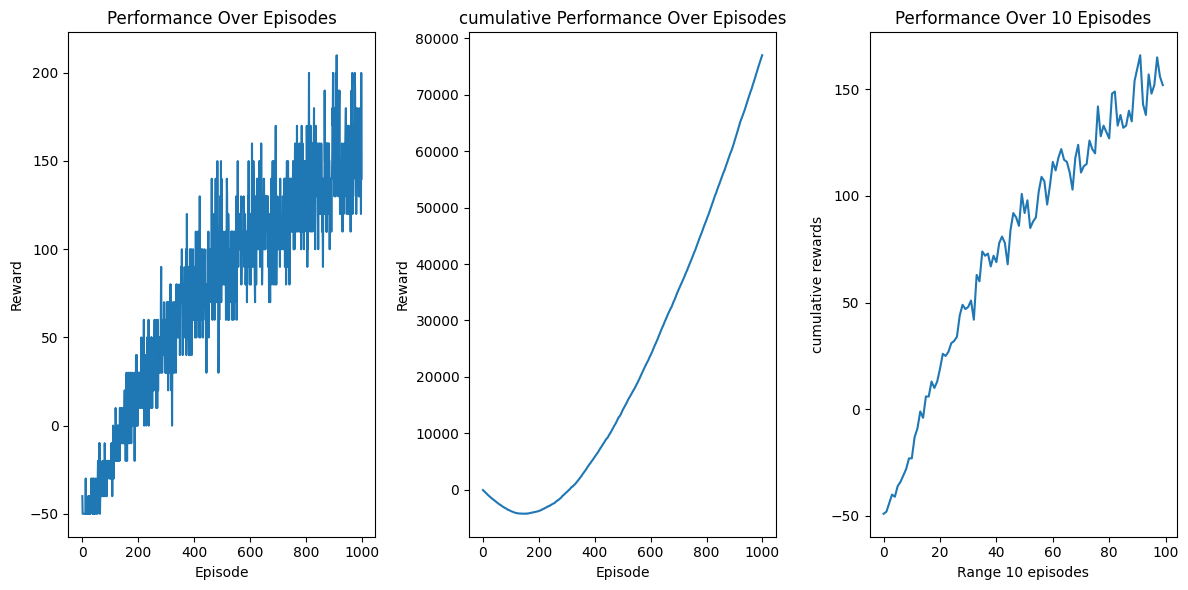

In [1295]:
# Plotting the rewards

plt.figure(figsize=(12, 6))


plt.subplot(1, 3, 1) 
plt.plot(rewards)
plt.xlabel('Episode')
plt.ylabel('Reward')
plt.title('Performance Over Episodes')
#plt.show()



# Plotting the cumulative sum

plt.subplot(1, 3, 2) 
#plt.figure(figsize=(8,8))
plt.plot(cumulative_scores)
plt.xlabel('Episode')
plt.ylabel('Reward')
plt.title('cumulative Performance Over Episodes')



plt.subplot(1, 3, 3) 
#plt.figure(figsize=(8,8))
plt.plot(reward_means)
plt.xlabel('Range 10 episodes')
plt.ylabel('cumulative rewards')
plt.title('Performance Over 10 Episodes')

plt.tight_layout()
plt.show()



Here we run 50 test episodes to check on the performance of our trained policy with an epsilon value of 0.

In [1296]:
import pickle

with open('trained_q_table.pkl', 'wb') as f:
    pickle.dump(Q_1, f)


Q-learning Test Average: 189.35000000000002, Standard Deviation: 21.01523257068548


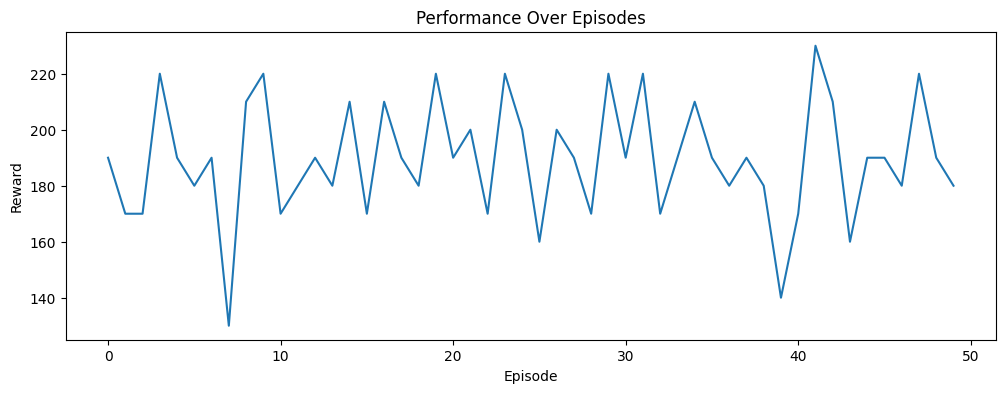

1000


In [1297]:
with open('trained_q_table.pkl', 'rb') as f:
    Q_1 = pickle.load(f)
steps=[]
test_rewards_q_learning = []
epsilon=0.0
for ep in range(50):
    total_reward = 0
    [x, y, theta], target_pos, episode, step = new_episode()
    step_count = 0
    step_to_target=0

    while True:
        state = get_state(x, y, theta, target_pos)
        action = max(available_actions, key=lambda a: Q.get((state, a), 0))
       
        omega_0,omega_1,omega_2=execute_action(action)    
        
        
        x,y,theta=update_pose(x, y, theta, omega_0, omega_1, omega_2)
        
        
        distance_to_target = math.sqrt((x - target_pos[0])**2 + (y - target_pos[1])**2)
        #print(distance_to_target)
        #robot_pose=[x,y,theta]
        reward = 0
    
        if distance_to_target <= ROBOT_RADIUS:
            step_to_target+=1
            
            [x,y,theta], target_pos, episode, step = new_episode(ep)
            reward += 10
   
        
        elif distance_to_target >= ROBOT_RADIUS:
            step_to_target += 1
        elif not FIELD.collidepoint(x, y):
            step_to_target +=1
            
            [x,y,theta], target_pos, episode, step = new_episode(ep)
            reward-=1
            
        
        reward -=(step_to_target*0.0001)
        
        total_reward+=reward
        
        
        step_count += 1
        
     
        
        if step_count >= max_steps_per_episode:
            break

    test_rewards_q_learning.append(total_reward)
    steps.append(step_to_target)

test_avg_q_learning = np.mean(test_rewards_q_learning)
test_std_q_learning = np.std(test_rewards_q_learning)

print(f"Q-learning Test Average: {test_avg_q_learning}, Standard Deviation: {test_std_q_learning}")

# Plotting the rewards
plt.figure(figsize=(12,4))
plt.plot(test_rewards_q_learning)
plt.xlabel('Episode')
plt.ylabel('Reward')
plt.title('Performance Over Episodes')
plt.show()
print(len(rewards))




Importing all necessary libraries and defining all functions.here we apply same procedure as step one with the difference being ourtarget is nowe the next target position and not the target's position. We find this by adding velocity to our current target poition.

In [1298]:
import pygame
import random
import math

# Initialise Pygame
pygame.init()

# Constants
WIDTH, HEIGHT = 800, 600
FIELD = pygame.Rect(50, 50, WIDTH-100, HEIGHT-100)
ROBOT_RADIUS = 20
WHEEL_RADIUS = 5
TARGET_RADIUS = 10
FONT = pygame.font.SysFont("Arial", 24)

def new_episode(episode = -1):
    robot_pose = [random.randint(FIELD.left, FIELD.right), 
                  random.randint(FIELD.top, FIELD.bottom),
                  random.randint(0,359)]    
    target_pos = [random.randint(FIELD.left, FIELD.right), 
                  random.randint(FIELD.top, FIELD.bottom)]
    target_vel = [random.uniform(0.2, 0.6),
                  random.uniform(-0.6, 0.6)]
    
    return robot_pose, target_pos, target_vel, episode + 1, 0


def clip(value, min_val = -1, max_val = 1):
    return max(min(value, max_val), min_val)


def update_pose(x, y, theta, omega_0, omega_1, omega_2, step_size=10):
    omega_0 = clip(omega_0)
    omega_1 = clip(omega_1)
    omega_2 = clip(omega_2)
    
    R = 0.5
    # d = 1.0
    V_x = R * (omega_0 * math.cos(math.radians(60)) +
               omega_1 * math.cos(math.radians(180)) +
               omega_2 * math.cos(math.radians(300)))
    V_y = R * (omega_0 * math.sin(math.radians(60)) +
               omega_1 * math.sin(math.radians(180)) +
               omega_2 * math.sin(math.radians(300)))
    V_x_rotated = (V_x * math.cos(math.radians(theta)) - 
                   V_y * math.sin(math.radians(theta)))
    V_y_rotated = (V_x * math.sin(math.radians(theta)) + 
                   V_y * math.cos(math.radians(theta)))

    omega = omega_0 + omega_1 + omega_2
    x_prime = x + V_x_rotated * step_size
    y_prime = y + V_y_rotated * step_size

    theta_prime = theta + omega * step_size
    theta_prime = theta_prime % 360
    return x_prime, y_prime, theta_prime

In [1299]:


# Start first episode
score = 0
running = True
omega_0, omega_1, omega_2 = 0, 0, 0

[x,y,theta], target_pos, target_vel, episode, step = new_episode()
print(target_vel)




screen = pygame.display.set_mode((WIDTH, HEIGHT))

while running:
    for event in pygame.event.get():
        if event.type == pygame.QUIT:
            running = False
        elif event.type == pygame.KEYDOWN:
            if event.key == pygame.K_q:
                running = False
    
    
    # Update target position so that thetarget position we are using is where the robot is heading too
    target_pos[0] += target_vel[0]
    target_pos[1] += target_vel[1]
    
    
    angle_to_target = math.degrees(math.atan2(target_pos[1] - y, target_pos[0] - x)) 
    relative_angle = (angle_to_target - theta + 360) % 360
    
    #relative_angle = (angle_to_target - theta + 360) % 360
    #angle_difference = abs(relative_angle)
    #orientation_reward = max(0, 90 - angle_difference)
    
    
   
    if 0 <= relative_angle <= 90:
        state=1
   
    elif 90 < relative_angle <= 180:
        state=2
    elif 180 < relative_angle <= 270:
        state=3
  
    else:
        state=4
        
    if state == 1:
        
        action=1
        omega_0, omega_1, omega_2 = 1, 0, 0
    
    elif state == 2:
        action=2
        omega_0, omega_1, omega_2 = 0, 1, 0
    
    elif state == 3:
        action=3
        omega_0, omega_1, omega_2 = 0, -1, 0

   
    else:
        action=3
        omega_0, omega_1, omega_2 = 0, 0, 1

    # Update robot
    #omega_0 = random.uniform(-1, 1)
    #omega_1 = random.uniform(-1, 1)
    #omega_2 = random.uniform(-1, 1)


    x, y, theta = update_pose(x, y, theta, omega_0, omega_1, omega_2)
    step += 1
    score -= 0.01

    # Update target position
    #target_pos[0] += target_vel[0]
    #target_pos[1] += target_vel[1]


    if target_pos[0] <= 50 or target_pos[0] >= WIDTH - 50:
        target_vel[0] = -target_vel[0]
    if target_pos[1] <= 50 or target_pos[1] >= HEIGHT - 50:
        target_vel[1] = -target_vel[1]

   
    distance_to_target = math.sqrt((x - target_pos[0])**2 + (y - target_pos[1])**2)
    if distance_to_target <=2* ROBOT_RADIUS:
        [x,y,theta], target_pos, target_vel, episode, step = new_episode(episode)
        score += 10
        
        
    elif not FIELD.collidepoint(x, y):
        [x,y,theta], target_pos, target_vel, episode, step = new_episode(episode)
        score -= 10
        
    elif step > 1000:
        [x,y,theta], target_pos, target_vel, episode, step = new_episode(episode)
        

    screen.fill((0, 0, 0))
    pygame.draw.rect(screen, (25, 25, 25), FIELD)

    pygame.draw.circle(screen, (200, 200, 200), (int(x), HEIGHT - int(y)), ROBOT_RADIUS)
    pygame.draw.circle(screen, (255, 165, 0), (int(target_pos[0]), HEIGHT - int(target_pos[1])), TARGET_RADIUS)
    

    for i, colour in zip([60, 180, 300], [(255, 0, 0), (255, 0, 255), (0, 0, 255)]):
        wheel_x = int(x + ROBOT_RADIUS * math.cos(math.radians(i + theta - 90)))
        wheel_y = HEIGHT - int(y - ROBOT_RADIUS * math.sin(math.radians(i + theta - 90)))
        pygame.draw.circle(screen, colour, (wheel_x, wheel_y), WHEEL_RADIUS)
    
    score_surface = FONT.render(f'Episode: {episode}  Step: {step}  Score: {score:.2f}', True, (255, 255, 255))
    screen.blit(score_surface, (WIDTH - 400, 10))
    
    pygame.display.flip()
    pygame.time.delay(50)
  


[0.36141507968444, 0.1350644462741719]


In [1300]:

# I broke down this function and run it run by line in the code itself as I needed to see how to move the target at different points.
def get_state(x, y, theta, target_pos,target_vel):
    target_pos[0] += target_vel[0]
    target_pos[1] += target_vel[1]
    angle_to_target = math.degrees(math.atan2(target_pos[1] - y, target_pos[0] - x)) 
    relative_angle = (angle_to_target - theta + 360) % 360
    
    
    if 0 <= relative_angle <= 90:
        return 1
   
    elif 90 < relative_angle <= 180:
        return 2
    elif 180 < relative_angle <= 270:
        return 3
   
    else:
        return 4


defining all necessary functions especially on execution of actions and assigning of rewards

In [1301]:

start_time = time.time()
import pygame
import random
import math
import numpy as np
# Initialise Pygame
pygame.init()

# Constants
WIDTH, HEIGHT = 800, 600
FIELD = pygame.Rect(50, 50, WIDTH-100, HEIGHT-100)
ROBOT_RADIUS = 20
WHEEL_RADIUS = 5
TARGET_RADIUS = 10
FONT = pygame.font.SysFont("Arial", 24)



def execute_action(action):
    # Define wheel velocities for different actions
    
    # Action 1
    if action == 1:
        omega_0, omega_1, omega_2 = 0, 0, 0  #move forward
        return omega_0, omega_1, omega_2
        

    # Action 2
    elif action == 2:
        omega_0, omega_1, omega_2 = 0, 0, 1  # move back
        return omega_0, omega_1, omega_2
        
        

    # Action 3
    elif action == 3:
        omega_0, omega_1, omega_2 = 0, 1, 0  # spin
        return omega_0, omega_1, omega_2
        
    
    # Action 4
    elif action == 4:
        omega_0, omega_1, omega_2 = 0, 1, 1  #
        return omega_0, omega_1, omega_2

    # Action 5
    elif action == 5:
        omega_0, omega_1, omega_2 = 1, 0, 0 
        return omega_0, omega_1, omega_2
       
    # Action 6
    elif action == 6:
        omega_0, omega_1, omega_2 = 1, 0, 1 
        return omega_0, omega_1, omega_2
       
    #Action 7
    elif action == 7:
        omega_0, omega_1, omega_2 = 1, 1, 0
        return omega_0, omega_1, omega_2
        
    # Action 8
    elif action == 8:
        omega_0, omega_1, omega_2 = 1, 1, 1 
        return omega_0, omega_1, omega_2
    #Action 9
    elif action == 9:
        omega_0, omega_1, omega_2 = 0, 0, -1
        return omega_0, omega_1, omega_2
    # Action 10
    elif action == 10:
        omega_0, omega_1, omega_2 = 0, -1, 0 
        return omega_0, omega_1, omega_2
    # Action 11
    elif action == 11:
        omega_0, omega_1, omega_2 = 0, -1, -1 
        return omega_0, omega_1, omega_2
      
    #Action 12
    elif action == 12:
        omega_0, omega_1, omega_2 = -1, 0, 0
        return omega_0, omega_1, omega_2
        
    # Action 13
    elif action == 13:
        omega_0, omega_1, omega_2 = -1, 0, -1
        return omega_0, omega_1, omega_2
       
    #Action 14
    elif action == 14:
        omega_0, omega_1, omega_2 = -1, -1, 0
        return omega_0, omega_1, omega_2
    #action15
    elif action == 15:
        omega_0, omega_1, omega_2 = -1, -1,-1
        return omega_0, omega_1, omega_2
    # Action 16
    elif action == 16:
        omega_0, omega_1, omega_2 = 1,1,-1
        return omega_0, omega_1, omega_2
    #Action 17
    elif action == 17:
        omega_0, omega_1, omega_2 = 1, -1, -1
        return omega_0, omega_1, omega_2
    # Action 18
    elif action == 18:
        omega_0, omega_1, omega_2 = -1, -1, 1 
        return omega_0, omega_1, omega_2
    #Action 19
    elif action == 19:
        omega_0, omega_1, omega_2 = -1, 1, -1
        return omega_0, omega_1, omega_2
     #Action 20
    elif action == 20:
        omega_0, omega_1, omega_2 = 1, -1, 1
        return omega_0, omega_1, omega_2
    # Action 21
    elif action == 21:
        omega_0, omega_1, omega_2 = -1, 1, 1
        return omega_0, omega_1, omega_2
    #Action 22
    elif action == 22:
        omega_0, omega_1, omega_2 = 0, 1, -1
        return omega_0, omega_1, omega_2
    #Action 23
    elif action == 23:
        omega_0, omega_1, omega_2 = 1, 0, -1
        return omega_0, omega_1, omega_2
    # Action 24
    elif action == 24:
        omega_0, omega_1, omega_2 = -1, 1, 0 
        return omega_0, omega_1, omega_2
    # Action 25
    elif action == 25:
        omega_0, omega_1, omega_2 =0,-1, 1
        return omega_0, omega_1, omega_2
    
    # Action 26
    elif action == 26:
        omega_0, omega_1, omega_2 =1,-1, 0
        return omega_0, omega_1, omega_2
    # Action 27
    elif action == 27:
        omega_0, omega_1, omega_2 =-1,0, 1
        return omega_0, omega_1, omega_2
    
    
    
    
    
    
def new_episode(episode = -1):
    robot_pose = [random.randint(FIELD.left, FIELD.right), 
                  random.randint(FIELD.top, FIELD.bottom),
                  random.randint(0,359)]    
    target_pos = [random.randint(FIELD.left, FIELD.right), 
                  random.randint(FIELD.top, FIELD.bottom)]
    target_vel = [random.uniform(0.2, 0.6),
                  random.uniform(-0.6, 0.6)]
    
    return robot_pose, target_pos, target_vel, episode + 1, 0


def clip(value, min_val = -1, max_val = 1):
    return max(min(value, max_val), min_val)

def get_state(x, y, theta, target_pos):
    angle_to_target = math.degrees(math.atan2(target_pos[1] - y, target_pos[0] - x)) 
    relative_angle = (angle_to_target - theta + 360) % 360
    
    # state 1: target in 1st quad
    if 0 <= relative_angle <= 90:
        return 1
    # state 2: target in 2nd quad
    elif 90 < relative_angle <= 180:
        return 2
    elif 180 < relative_angle <= 270:
        return 3
    # state 3: other
    else:
        return 4



def update_pose(x, y, theta, omega_0, omega_1, omega_2, step_size=10):
    omega_0 = clip(omega_0)
    omega_1 = clip(omega_1)
    omega_2 = clip(omega_2)
    
    R = 0.5
    # d = 1.0
    V_x = R * (omega_0 * math.cos(math.radians(60)) +
               omega_1 * math.cos(math.radians(180)) +
               omega_2 * math.cos(math.radians(300)))
    V_y = R * (omega_0 * math.sin(math.radians(60)) +
               omega_1 * math.sin(math.radians(180)) +
               omega_2 * math.sin(math.radians(300)))
    V_x_rotated = (V_x * math.cos(math.radians(theta)) - 
                   V_y * math.sin(math.radians(theta)))
    V_y_rotated = (V_x * math.sin(math.radians(theta)) + 
                   V_y * math.cos(math.radians(theta)))

    omega = omega_0 + omega_1 + omega_2
    x_prime = x + V_x_rotated * step_size
    y_prime = y + V_y_rotated * step_size

    theta_prime = theta + omega * step_size
    theta_prime = theta_prime % 360
    return x_prime, y_prime, theta_prime

def get_state(x, y, theta, target_pos):
    #target_pos[0] += target_vel[0]
    #target_pos[1] += target_vel[1]
    angle_to_target = math.degrees(math.atan2(target_pos[1] - y, target_pos[0] - x)) 
    relative_angle = (angle_to_target - theta + 360) % 360
    
    
    if 0 <= relative_angle <= 90:
        return 1
  
    elif 90 < relative_angle <= 180:
        return 2
    elif 180 < relative_angle <= 270:
        return 3
    
    else:
        return 4


In [1302]:

# Start first episode

start_time = time.time()

alpha = 0.08 
gamma = 0.9
epsilon = 1  
decay_rate=0.998

#patience =200
best_avg_reward = -np.inf  
stall_counter = 0 

available_actions=range(1,27)
cumulative_scores=[]


Q = {(s, a): 0 for s in range(1, 5) for a in range(1, 27)}

steps=[]
rewards=[]
score = 0
running = True
rewardspp=[]







screen = pygame.display.set_mode((WIDTH, HEIGHT))

num_episodes = 1000  
max_steps_per_episode = 1000 


for episode in range(num_episodes):
    
    [x, y, theta], target_pos, target_vel, episode, step = new_episode(episode)
    
    
    total_reward = 0
    step_to_target=0
    
    
    
    #print(episode)

    while True:
        
        
        for event in pygame.event.get():
            if event.type == pygame.QUIT:
                running = False
            elif event.type == pygame.KEYDOWN:
                if event.key == pygame.K_q:
                    running = False
        target_pos[0] += target_vel[0]
        target_pos[1] += target_vel[1]

        state = get_state(x, y, theta, target_pos)
        
        if random.uniform(0, 1) < epsilon:
            action = random.randint(1, len(available_actions))
        else:
            action = max(available_actions, key=lambda a: Q.get((state, a), 0))

        omega_0,omega_1,omega_2=execute_action(action)
        
        
        
        
        

        
        x, y, theta = update_pose(x, y, theta, omega_0, omega_1, omega_2)
        

        

        angle_to_target = math.degrees(math.atan2(target_pos[1] - y, target_pos[0] - x))
        distance_to_target = math.sqrt((x - target_pos[0])**2 + (y - target_pos[1])**2)
        relative_angle = (angle_to_target - theta + 360) % 360

        reward = 0

        if distance_to_target <= ROBOT_RADIUS:
            step_to_target +=1
            [x, y, theta], target_pos, target_vel, episode, step = new_episode(episode)
            #print("episode ends here 1",step)
            reward += 10
            break
        
        
        #elif state == 1 and action == 5:
            #reward += 1
        # state 2: target in 2nd quad
        
        #elif state == 2 and action == 3:
            #reward += 1
        #elif state == 3 and action == 10:
            #reward += 1
        # state 3: other
        #elif state == 4 and action == 1:
            #reward += 1
        if distance_to_target >= ROBOT_RADIUS:
            step_to_target +=1
            
        elif not FIELD.collidepoint(x, y):
            step_to_target +=1
            [x, y, theta], target_pos, target_vel, episode, step = new_episode(episode)
            #print("episode ends here 2",step)
            reward-=1
            break

        reward -= step_to_target*0.0001
        #reward -= 0.1
        rewardspp.append(reward)

        total_reward+=reward
        #print(total_reward)
        
        #target_pos[0] += target_vel[0]
        #target_pos[1] += target_vel[1]
        next_state = get_state(x, y, theta, target_pos)
        
        Q[(state, action)] = (1 - alpha) * Q[(state, action)] + alpha * (reward + gamma * max(Q[(next_state, a)] for a in available_actions) - Q[(state, action)])
        step += 1
        
        
        if step > max_steps_per_episode:
            step_to_target +=1
            [x, y, theta], target_pos, target_vel, episode, step = new_episode(episode)
            #print("episode ends here",step)
            break
        
            
        

       
        if target_pos[0] <= 50 or target_pos[0] >= WIDTH - 50:
            target_vel[0] = -target_vel[0]
        if target_pos[1] <= 50 or target_pos[1] >= HEIGHT - 50:
            target_vel[1] = -target_vel[1]
    steps.append(step_to_target)    
    rewards.append(total_reward)
    

    
    
   
   


    screen.fill((0, 0, 0))
    pygame.draw.rect(screen, (25, 25, 25), FIELD)

    pygame.draw.circle(screen, (200, 200, 200), (int(x), HEIGHT - int(y)), ROBOT_RADIUS)
    pygame.draw.circle(screen, (255, 165, 0), (int(target_pos[0]), HEIGHT - int(target_pos[1])), TARGET_RADIUS)

    # Draw Wheels
    for i, colour in zip([60, 180, 300], [(255, 0, 0), (255, 0, 255), (0, 0, 255)]):
        wheel_x = int(x + ROBOT_RADIUS * math.cos(math.radians(i + theta - 90)))
        wheel_y = HEIGHT - int(y - ROBOT_RADIUS * math.sin(math.radians(i + theta - 90)))
        pygame.draw.circle(screen, colour, (wheel_x, wheel_y), WHEEL_RADIUS)

    score_surface = FONT.render(f'Episode: {episode}  Step: {step}  reward: {reward:.2f}', True, (255, 255, 255))
    screen.blit(score_surface, (WIDTH - 400, 10))

    epsilon = max(epsilon * decay_rate, 0.01)

    pygame.display.flip()
    pygame.time.delay(1)
    
    cumulative_scores.append(np.sum(rewards))
end_time = time.time()
elapsed_time = end_time - start_time


print(f"Time taken: {elapsed_time} seconds")

Time taken: 7.935472011566162 seconds


In [1303]:
reward_means = []


for i in range(0, len(rewards), 10):
    group = rewards[i:i+10]  
    group_mean = np.mean(group) 
    reward_means.append(group_mean)  


len(reward_means)

100

In [1304]:
np.mean(rewards)

-19.586055499999997

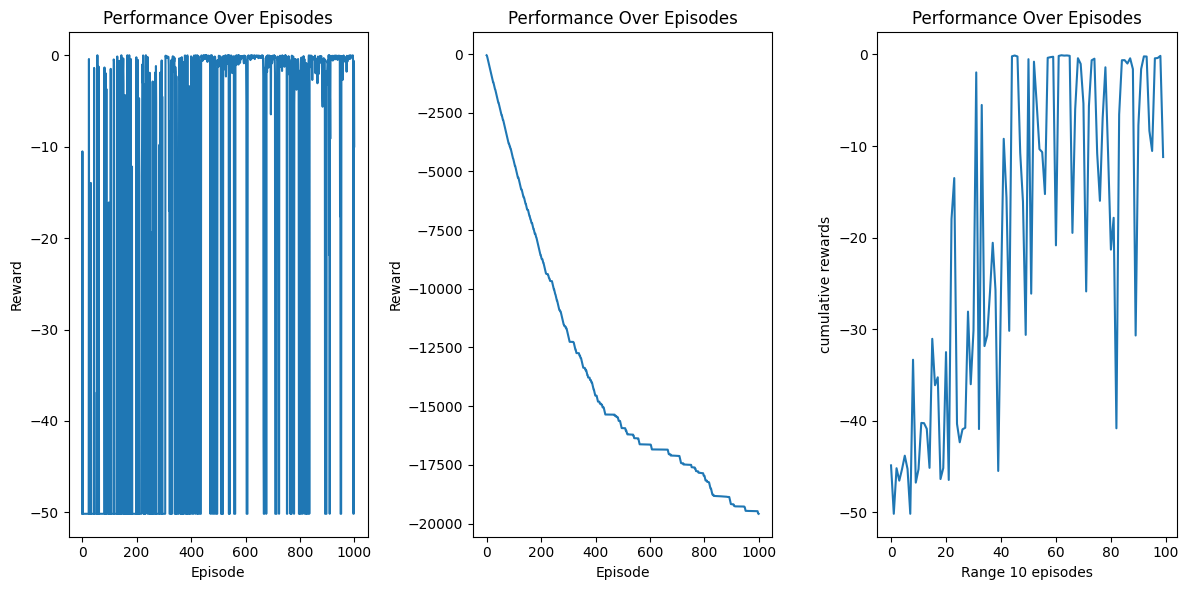

In [1305]:
# Plotting the rewards

plt.figure(figsize=(12, 6))


plt.subplot(1, 3, 1) 
plt.plot(rewards)
plt.xlabel('Episode')
plt.ylabel('Reward')
plt.title('Performance Over Episodes')
#plt.show()



# Plotting the cumulative sum

plt.subplot(1, 3, 2) 
#plt.figure(figsize=(8,8))
plt.plot(cumulative_scores)
plt.xlabel('Episode')
plt.ylabel('Reward')
plt.title('Performance Over Episodes')



plt.subplot(1, 3, 3) 
#plt.figure(figsize=(8,8))
plt.plot(reward_means)
plt.xlabel('Range 10 episodes')
plt.ylabel('cumulative rewards')
plt.title('Performance Over Episodes')

plt.tight_layout()
plt.show()




here we test the policy with 50 episodes and a value of epsilon being 0

In [1306]:
import pickle

with open('trained_q_table.pkl', 'wb') as f:
    pickle.dump(Q, f)


In [1307]:
pygame.init()
screen = pygame.display.set_mode((WIDTH, HEIGHT))

start_time = time.time()
import pickle
import pygame
import random
import math
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)

pygame.init()




with open('trained_q_table.pkl', 'rb') as f:
    Q = pickle.load(f)

epsilon = 0.0

test_rewards_q_learning = []


for ep in range(50):
    total_reward = 0
    [x, y, theta], target_pos, target_vel, episode, step = new_episode(ep)

    step_count = 0
    step_to_target=0

    while True:
        target_pos[0] += target_vel[0]
        target_pos[1] += target_vel[1]
        
        
        state = get_state(x, y, theta, target_pos)
        action = max(available_actions, key=lambda a: Q.get((state, a), 0))
        
        omega_o,omega_1,omega_2= execute_action(action)
        x, y, theta = update_pose(x, y, theta, omega_0, omega_1, omega_2)

        
        
        
        distance_to_target = math.sqrt((x - target_pos[0])**2 + (y - target_pos[1])**2)
        
        reward = 0
    
        if distance_to_target <= ROBOT_RADIUS:
            step_to_target+=1
            [x, y, theta], target_pos, target_vel, episode, step = new_episode(episode)
            #print("episode ends here 1",step)
            reward += 10
            
        
        
        #elif state == 1 and action == 5:
            #reward += 1
        # state 2: target in 2nd quad
        
        #elif state == 2 and action == 3:
            #reward += 1
        #elif state == 3 and action == 10:
            #reward += 1
        # state 3: other
        #elif state == 4 and action == 1:
            #reward += 1
        if distance_to_target >= ROBOT_RADIUS:
            step_to_target+=1
        elif not FIELD.collidepoint(x, y):
            step_to_target+=1
            [x, y, theta], target_pos, target_vel, episode, step = new_episode(episode)
            #print("episode ends here 2",step)
            reward-=10
           
        
        reward -= 0.001*step_to_target
        
        total_reward += reward

        # Update the target position within the main loop
        
        # Execute action and update the robot's position
       
        step_count += 1
        
        
        

        if step_count >= max_steps_per_episode or not FIELD.collidepoint(x, y):
            break
        
        
    screen.fill((0, 0, 0))
    pygame.draw.rect(screen, (25, 25, 25), FIELD)

    pygame.draw.circle(screen, (200, 200, 200), (int(x), HEIGHT - int(y)), ROBOT_RADIUS)
    pygame.draw.circle(screen, (255, 165, 0), (int(target_pos[0]), HEIGHT - int(target_pos[1])), TARGET_RADIUS)

    # Draw Wheels
    for i, colour in zip([60, 180, 300], [(255, 0, 0), (255, 0, 255), (0, 0, 255)]):
        wheel_x = int(x + ROBOT_RADIUS * math.cos(math.radians(i + theta - 90)))
        wheel_y = HEIGHT - int(y - ROBOT_RADIUS * math.sin(math.radians(i + theta - 90)))
        pygame.draw.circle(screen, colour, (wheel_x, wheel_y), WHEEL_RADIUS)

    score_surface = FONT.render(f'Episode: {episode}  Step: {step}  reward: {reward:.2f}', True, (255, 255, 255))
    screen.blit(score_surface, (WIDTH - 400, 10))

    

    pygame.display.flip()
    pygame.time.delay(1)

    test_rewards_q_learning.append(total_reward)
    steps.append(step_to_target)
    

    test_rewards_q_learning.append(total_reward)
    
    

# Calculate average and standard deviation of rewards
test_avg_q_learning = np.mean(test_rewards_q_learning)
test_std_q_learning = np.std(test_rewards_q_learning)

print(f"Q-learning Test Average: {test_avg_q_learning}, Standard Deviation: {test_std_q_learning}")

end_time = time.time()
elapsed_time = end_time - start_time


print(f"Time taken: {elapsed_time} seconds")


Q-learning Test Average: -0.4984400000000001, Standard Deviation: 0.5666063240028303
Time taken: 0.11130213737487793 seconds


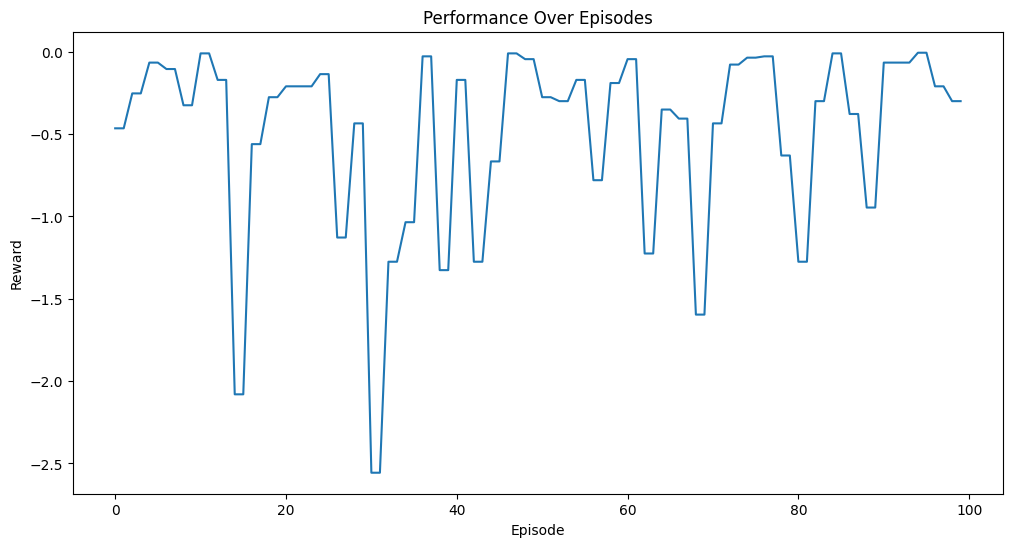

In [1308]:
# Plotting the rewards
plt.figure(figsize=(12, 6))
plt.plot(test_rewards_q_learning)
plt.xlabel('Episode')
plt.ylabel('Reward')
plt.title('Performance Over Episodes')
plt.show()

Q-learning Test Average: -50.05000000000001, Standard Deviation: 1.4210854715202004e-14


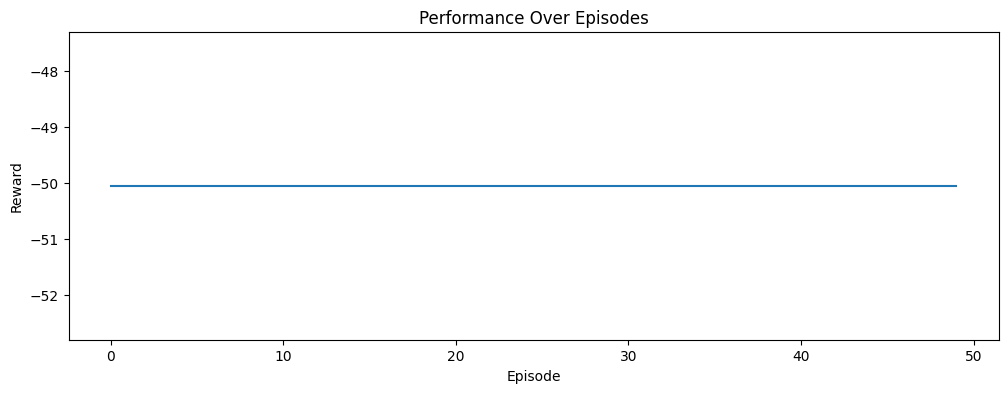

Time taken: 0.417888879776001 seconds


In [1309]:

pygame.init()
screen = pygame.display.set_mode((WIDTH, HEIGHT))
start_time = time.time()
with open('trained_q_table.pkl', 'rb') as f:
    Q = pickle.load(f)
steps=[]
test_rewards_q_learning = []
epsilon=0.0
for ep in range(50):
    total_reward = 0
    [x, y, theta], target_pos, target_vel, episode, step = new_episode(ep)
    step_count = 0
    step_to_target=0

    while True:
        state = get_state(x, y, theta, target_pos)
        action = max(available_actions, key=lambda a: Q.get((state, a), 0))
        
        omega_o,omega_1,omega_2= execute_action(action)
        x, y, theta = update_pose(x, y, theta, omega_0, omega_1, omega_2)

        
        
        distance_to_target = math.sqrt((x - target_pos[0])**2 + (y - target_pos[1])**2)
        #print(distance_to_target)
        #robot_pose=[x,y,theta]
        reward = 0
    
        if distance_to_target <= ROBOT_RADIUS:
            step_to_target+=1
            
            [x, y, theta], target_pos, target_vel, episode, step = new_episode(ep)
            reward += 10
            
        
        
        #elif state == 1 and action==5:
            #reward += 1
        #elif state == 2 and action==3:
            #reward += 1
        #elif state == 3 and action==10:
            #reward += 1
        #elif state == 4 and action==2:
            #reward += 1
        
        elif distance_to_target >= ROBOT_RADIUS:
            step_to_target += 1
        elif not FIELD.collidepoint(x, y):
            step_to_target +=1
            
            [x, y, theta], target_pos, target_vel, episode, step = new_episode(ep)
            reward-=10
            
        
        reward -=(step_to_target*0.0001)
        
        total_reward+=reward
        
        
        step_count += 1
    
        
        if step_count >= max_steps_per_episode:
            break
            
        if target_pos[0] <= 50 or target_pos[0] >= WIDTH - 50:
            target_vel[0] = -target_vel[0]
        if target_pos[1] <= 50 or target_pos[1] >= HEIGHT - 50:
            target_vel[1] = -target_vel[1]
    steps.append(step_to_target)    
    rewards.append(total_reward)
    

    
    
   
   


    screen.fill((0, 0, 0))
    pygame.draw.rect(screen, (25, 25, 25), FIELD)

    pygame.draw.circle(screen, (200, 200, 200), (int(x), HEIGHT - int(y)), ROBOT_RADIUS)
    pygame.draw.circle(screen, (255, 165, 0), (int(target_pos[0]), HEIGHT - int(target_pos[1])), TARGET_RADIUS)

    # Draw Wheels
    for i, colour in zip([60, 180, 300], [(255, 0, 0), (255, 0, 255), (0, 0, 255)]):
        wheel_x = int(x + ROBOT_RADIUS * math.cos(math.radians(i + theta - 90)))
        wheel_y = HEIGHT - int(y - ROBOT_RADIUS * math.sin(math.radians(i + theta - 90)))
        pygame.draw.circle(screen, colour, (wheel_x, wheel_y), WHEEL_RADIUS)

    score_surface = FONT.render(f'Episode: {episode}  Step: {step}  reward: {reward:.2f}', True, (255, 255, 255))
    screen.blit(score_surface, (WIDTH - 400, 10))

    

    pygame.display.flip()
    pygame.time.delay(1)

    test_rewards_q_learning.append(total_reward)
    steps.append(step_to_target)
    

test_avg_q_learning = np.mean(test_rewards_q_learning)
test_std_q_learning = np.std(test_rewards_q_learning)

print(f"Q-learning Test Average: {test_avg_q_learning}, Standard Deviation: {test_std_q_learning}")

# Plotting the rewards
plt.figure(figsize=(12,4))
plt.plot(test_rewards_q_learning)
plt.xlabel('Episode')
plt.ylabel('Reward')
plt.title('Performance Over Episodes')
plt.show()

end_time = time.time()
elapsed_time = end_time - start_time


print(f"Time taken: {elapsed_time} seconds")



Here we implement a neural network, we define all functions needed to run, I make changes to the get state changing its out put from int to 1 1by 4 vector, this is becuse the beural network defined takes in 4 inputs which are then advanced to 16 inputs for the first layer. Since our state is 1 by 4 and the input is 4 by 16 the result of this multiplication is 1 by 16, the 16 goes into the first layer.

In [1310]:
import pygame
import random
import math
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

pygame.init()


WIDTH, HEIGHT = 800, 600
FIELD = pygame.Rect(50, 50, WIDTH - 100, HEIGHT - 100)
ROBOT_RADIUS = 20
WHEEL_RADIUS = 5
TARGET_RADIUS = 10
FONT = pygame.font.SysFont("Arial", 24)


def execute_action(action):

    
    # Action 1
    if action == 1:
        omega_0, omega_1, omega_2 = 0, 0, 0 
        return omega_0, omega_1, omega_2
        

    # Action 2
    elif action == 2:
        omega_0, omega_1, omega_2 = 0, 0, 1 
        return omega_0, omega_1, omega_2
        
        

    # Action 3
    elif action == 3:
        omega_0, omega_1, omega_2 = 0, 1, 0 
        return omega_0, omega_1, omega_2
        
    
    # Action 4
    elif action == 4:
        omega_0, omega_1, omega_2 = 0, 1, 1  #
        return omega_0, omega_1, omega_2

    # Action 5
    elif action == 5:
        omega_0, omega_1, omega_2 = 1, 0, 0 
        return omega_0, omega_1, omega_2
       
    # Action 6
    elif action == 6:
        omega_0, omega_1, omega_2 = 1, 0, 1 
        return omega_0, omega_1, omega_2
       
    #Action 7
    elif action == 7:
        omega_0, omega_1, omega_2 = 1, 1, 0
        return omega_0, omega_1, omega_2
        
    # Action 8
    elif action == 8:
        omega_0, omega_1, omega_2 = 1, 1, 1 
        return omega_0, omega_1, omega_2
    #Action 9
    elif action == 9:
        omega_0, omega_1, omega_2 = 0, 0, -1
        return omega_0, omega_1, omega_2
    # Action 10
    elif action == 10:
        omega_0, omega_1, omega_2 = 0, -1, 0 
        return omega_0, omega_1, omega_2
    # Action 11
    elif action == 11:
        omega_0, omega_1, omega_2 = 0, -1, -1 
        return omega_0, omega_1, omega_2
      
    #Action 12
    elif action == 12:
        omega_0, omega_1, omega_2 = -1, 0, 0
        return omega_0, omega_1, omega_2
        
    # Action 13
    elif action == 13:
        omega_0, omega_1, omega_2 = -1, 0, -1
        return omega_0, omega_1, omega_2
       
    #Action 14
    elif action == 14:
        omega_0, omega_1, omega_2 = -1, -1, 0
        return omega_0, omega_1, omega_2
    #action15
    elif action == 15:
        omega_0, omega_1, omega_2 = -1, -1,-1
        return omega_0, omega_1, omega_2
    # Action 16
    elif action == 16:
        omega_0, omega_1, omega_2 = 1,1,-1
        return omega_0, omega_1, omega_2
    #Action 17
    elif action == 17:
        omega_0, omega_1, omega_2 = 1, -1, -1
        return omega_0, omega_1, omega_2
    # Action 18
    elif action == 18:
        omega_0, omega_1, omega_2 = -1, -1, 1 
        return omega_0, omega_1, omega_2
    #Action 19
    elif action == 19:
        omega_0, omega_1, omega_2 = -1, 1, -1
        return omega_0, omega_1, omega_2
     #Action 20
    elif action == 20:
        omega_0, omega_1, omega_2 = 1, -1, 1
        return omega_0, omega_1, omega_2
    # Action 21
    elif action == 21:
        omega_0, omega_1, omega_2 = -1, 1, 1
        return omega_0, omega_1, omega_2
    #Action 22
    elif action == 22:
        omega_0, omega_1, omega_2 = 0, 1, -1
        return omega_0, omega_1, omega_2
    #Action 23
    elif action == 23:
        omega_0, omega_1, omega_2 = 1, 0, -1
        return omega_0, omega_1, omega_2
    # Action 24
    elif action == 24:
        omega_0, omega_1, omega_2 = -1, 1, 0 
        return omega_0, omega_1, omega_2
    # Action 25
    elif action == 25:
        omega_0, omega_1, omega_2 = 0, -1, 1
        return omega_0, omega_1, omega_2
    
    # Action 26
    elif action == 26:
        omega_0, omega_1, omega_2 =1,-1, 0
        return omega_0, omega_1, omega_2
    # Action 27
    elif action == 27:
        omega_0, omega_1, omega_2 =-1,0, 1
        return omega_0, omega_1, omega_2
    else:
        omega_0, omega_1, omega_2 = 0, 0, 0
    return omega_0, omega_1, omega_2
    
    
    
    
    


'''def new_episode(episode = -1):
    robot_pose = [random.randint(FIELD.left, FIELD.right), 
                  random.randint(FIELD.top, FIELD.bottom),
                  random.randint(0,359)]    
    target_pos = [random.randint(FIELD.left, FIELD.right), 
                  random.randint(FIELD.top, FIELD.bottom)]
    target_vel = [random.uniform(0.2, 0.6),
                  random.uniform(-0.6, 0.6)]
    
    return robot_pose, target_pos, target_vel, episode + 1, 0'''


import random

def new_episode(episode=-1):
    max_distance = max(50, episode) if episode < 1000 else 9999

    while True:
        robot_pose = [
            random.randint(FIELD.left, FIELD.right),
            random.randint(FIELD.top, FIELD.bottom),
            random.randint(0, 359)
        ]

        target_pos = [
            random.randint(FIELD.left, FIELD.right),
            random.randint(FIELD.top, FIELD.bottom)
        ]

        def distance(x, y):
            return ((x[0] - y[0]) ** 2 + (x[1] - y[1]) ** 2) ** 0.5

        d = distance(robot_pose, target_pos)

        if d <= max_distance:
            break

    target_vel = [
        random.uniform(0.2, 0.6),
        random.uniform(-0.6, 0.6)
    ]

    return robot_pose, target_pos, target_vel, episode + 1, 0



def clip(value, min_val = -1, max_val = 1):
    return max(min(value, max_val), min_val)

def get_state(x, y, theta, target_pos):
    angle_to_target = math.degrees(math.atan2(target_pos[1] - y, target_pos[0] - x)) 
    relative_angle = (angle_to_target - theta + 360) % 360
    
    # state 1: target in 1st quad
    if 0 <= relative_angle <= 90:
        return torch.tensor([[1,0,0,0]],dtype=torch.float32)
    # state 2: target in 2nd quad
    elif 90 < relative_angle <= 180:
        return torch.tensor([[0,1,0,0]],dtype=torch.float32)
    elif 180 < relative_angle <= 270:
        return torch.tensor([[0,0,1,0]],dtype=torch.float32)
    # state 3: other
    else:
        return torch.tensor([[0,0,0,1]],dtype=torch.float32)



def update_pose(x, y, theta, omega_0, omega_1, omega_2, step_size=100):
    omega_0 = clip(omega_0)
    omega_1 = clip(omega_1)
    omega_2 = clip(omega_2)
    
    R = 0.5
    # d = 1.0
    V_x = R * (omega_0 * math.cos(math.radians(60)) +
               omega_1 * math.cos(math.radians(180)) +
               omega_2 * math.cos(math.radians(300)))
    V_y = R * (omega_0 * math.sin(math.radians(60)) +
               omega_1 * math.sin(math.radians(180)) +
               omega_2 * math.sin(math.radians(300)))
    V_x_rotated = (V_x * math.cos(math.radians(theta)) - 
                   V_y * math.sin(math.radians(theta)))
    V_y_rotated = (V_x * math.sin(math.radians(theta)) + 
                   V_y * math.cos(math.radians(theta)))

    omega = omega_0 + omega_1 + omega_2
    x_prime = x + V_x_rotated * step_size
    y_prime = y + V_y_rotated * step_size

    theta_prime = theta + omega * step_size
    theta_prime = theta_prime % 360
    return x_prime, y_prime, theta_prime



    
def calculate_reward(distance_to_target, state, action):
    reward = 0

    if distance_to_target <= ROBOT_RADIUS:
        reward += 200
    elif distance_to_target <= 2 * ROBOT_RADIUS:
        reward += 100
    elif distance_to_target <= 3 * ROBOT_RADIUS:
        reward += 50
    elif state == 1 and action == 5:
        reward += 5
    elif state == 2 and action == 3:
        reward += 5
    elif state == 3 and action == 10:
        reward += 5
    elif state == 4 and action == 1:
        reward += 5

    reward -= 0.1

    return reward

def sample_action_from_probs(action_probs):
  
    action_probs = action_probs.detach().numpy()
    
    
    action_index = np.random.choice(len(action_probs[0]), p=action_probs[0])
    
  
    action = torch.tensor(action_index)
    
    return action

Our neural network has 2 hidden layers with 16 nodes each, accepts an input of 4 and its output dimensions is 27, we are using  a softmax activations so the 27 outputs are all probability ditributions.We obtain the index of our largest probability and that is defined as our next action , we then execute the action, calculate the rewards and append the episode trajectory.

In [1311]:
start_time = time.time()

screen = pygame.display.set_mode((WIDTH, HEIGHT))
import torch.nn.functional as F 


class PolicyNetwork(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(PolicyNetwork, self).__init__()
        self.fc1 = nn.Linear(input_dim, 16)
        self.fc2 = nn.Linear(16, output_dim)
        self.softmax = nn.Softmax(dim=-1)

    def forward(self, state):
        #state = state.view(-1, state.size(-1))
        x = torch.relu(self.fc1(state))
        action_logits = self.fc2(x)
        return action_logits

    def select_action(self, state):
        action_logits = self.forward(state)
        action_probs = self.softmax(action_logits)
        return action_probs

input_dim = 4
output_dim = 27  
policy_net = PolicyNetwork(input_dim, output_dim)
#default_action=5

optimizer = optim.Adam(policy_net.parameters(), lr=0.06)

steps=[]

num_episodes = 1000
max_steps_per_episode = 1000
total_returns=[]

for episode in range(num_episodes):
 
    [x, y, theta], target_pos, target_vel, episode, step = new_episode(episode)
    
    
    episode_trajectory = []
    
    
    done = False
    total_reward=0
    step_counter = 0
    step_to_target=0
    while not done and step < max_steps_per_episode:
        
        target_pos[0] += target_vel[0]
        target_pos[1] += target_vel[1]
        
        state = get_state(x, y, theta, target_pos)
        
        state = torch.tensor(state, dtype=torch.float32).view(1,-1)
        
        
        action_probs = policy_net.forward(state)
        action_probs_tensor = torch.tensor(action_probs, dtype=torch.float32)


        action_probs_tensor = F.softmax(action_probs_tensor, dim=-1)


        action_probs_tensor = action_probs_tensor.squeeze()
        max_index = torch.argmax(action_probs_tensor)
        
    

        action = max_index.item() + 1
        
        
        #if action < 0 or action >= len(action_probs):
            #action = default_action

    
       
        omega_0,omega_1,omega_2= execute_action(action)
        x, y, theta = update_pose(x, y, theta, omega_0, omega_1, omega_2)
        
        distance_to_target = math.sqrt((x - target_pos[0])**2 + (y - target_pos[1])**2)
        reward = 0
    
        if distance_to_target <= ROBOT_RADIUS:
            step_to_target+=1
            [x, y, theta], target_pos, target_vel, episode, step = new_episode(episode)
            
            reward += 10
            
        
        
        #elif state == 1 and action == 5:
            #reward += 1
        # state 2: target in 2nd quad
        
        #elif state == 2 and action == 3:
            #reward += 1
        #elif state == 3 and action == 10:
            #reward += 1
        # state 3: other
        #elif state == 4 and action == 1:
            #reward += 1
        if distance_to_target >= ROBOT_RADIUS:
            step_to_target+=1
        elif not FIELD.collidepoint(x, y):
            step_to_target+=1
            [x, y, theta], target_pos, target_vel, episode, step = new_episode(episode)
           
            reward-=0.1
           
        
        reward -= 0.001*step_to_target
        
        total_reward += reward
        
        
        target_pos[0] += target_vel[0]
        target_pos[1] += target_vel[1]
        
        
        
        
        next_state = get_state(x, y, theta, target_pos)
        
        
        episode_trajectory.append((state, action, reward))
        
        
        state = next_state
        
       
        step += 1
        
        
        
        if target_pos[0] <= 50 or target_pos[0] >= WIDTH - 50:
            target_vel[0] = -target_vel[0]
        if target_pos[1] <= 50 or target_pos[1] >= HEIGHT - 50:
            target_vel[1] = -target_vel[1]

        
        if distance_to_target <= TARGET_RADIUS:
            done = True

    
    total_return = sum(r for (_, _, r) in episode_trajectory)
    #print(total_return)
    total_returns.append(total_return)
    steps.append(step_to_target)
    
    
    screen.fill((0, 0, 0))
    pygame.draw.rect(screen, (25, 25, 25), FIELD)

    pygame.draw.circle(screen, (200, 200, 200), (int(x), HEIGHT - int(y)), ROBOT_RADIUS)
    pygame.draw.circle(screen, (255, 165, 0), (int(target_pos[0]), HEIGHT - int(target_pos[1])), TARGET_RADIUS)

   
    for i, colour in zip([60, 180, 300], [(255, 0, 0), (255, 0, 255), (0, 0, 255)]):
        wheel_x = int(x + ROBOT_RADIUS * math.cos(math.radians(i + theta - 90)))
        wheel_y = HEIGHT - int(y - ROBOT_RADIUS * math.sin(math.radians(i + theta - 90)))
        pygame.draw.circle(screen, colour, (wheel_x, wheel_y), WHEEL_RADIUS)

    score_surface = FONT.render(f'Episode: {episode}', True, (255, 255, 255))
    screen.blit(score_surface, (WIDTH - 400, 10))

  

    pygame.display.flip()
    pygame.time.delay(1)
    
    


    total_return = sum(r for (_, _, r) in episode_trajectory)

    policy_loss = 0
    for (s, a, _) in episode_trajectory:
        action_probs = policy_net(torch.tensor(s, dtype=torch.float32))
        action_probs = F.softmax(action_probs, dim=-1).squeeze()
        action_probs = action_probs.clamp(min=1e-8)  
        action_log_probs = torch.log(action_probs)
        a = min(max(a, 0), output_dim - 1)
        policy_loss -= action_log_probs[a] * total_return

    optimizer.zero_grad()
    policy_loss.backward()
    optimizer.step()
    

end_time = time.time()
elapsed_time = end_time - start_time


print(f"Time taken: {elapsed_time} seconds")
  

print(np.mean(total_returns)) 


/var/folders/5y/466mqc5d1c9722h6thyb41hr0000gn/T/ipykernel_21683/2762055290.py:57: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  state = torch.tensor(state, dtype=torch.float32).view(1,-1)
/var/folders/5y/466mqc5d1c9722h6thyb41hr0000gn/T/ipykernel_21683/2762055290.py:61: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  action_probs_tensor = torch.tensor(action_probs, dtype=torch.float32)
/var/folders/5y/466mqc5d1c9722h6thyb41hr0000gn/T/ipykernel_21683/2762055290.py:181: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  action_probs = policy_net(

Time taken: 131.80224990844727 seconds
-493.164667


## Question 3

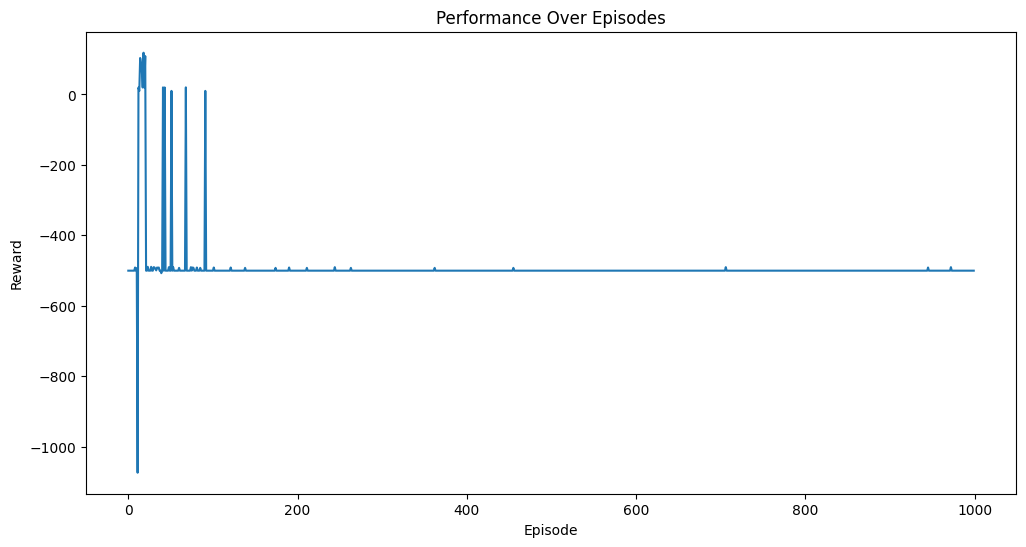

In [1312]:

plt.figure(figsize=(12, 6))
plt.plot(total_returns)
plt.xlabel('Episode')
plt.ylabel('Reward')
plt.title('Performance Over Episodes')
plt.show()


Here we train the policy above for 50 episodes

Test-Average: -112.52
Test-Standard-Deviation: 36.08


/var/folders/5y/466mqc5d1c9722h6thyb41hr0000gn/T/ipykernel_21683/3857107585.py:21: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  state = torch.tensor(state, dtype=torch.float32)


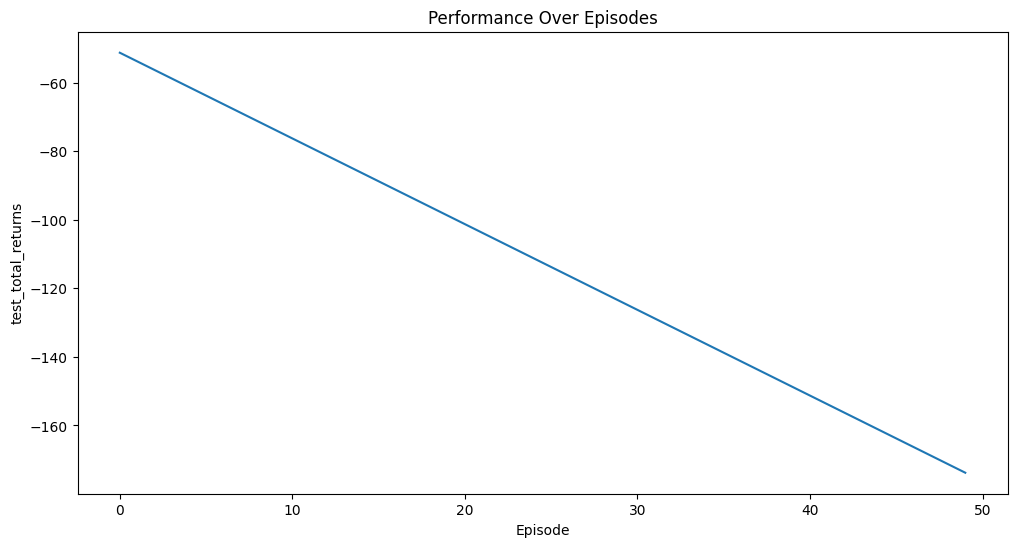

In [1313]:
import pygame
import math


num_test_episodes = 50
max_epochs_per_episode =50
test_total_returns = []


for episode in range(num_test_episodes):
    [x, y, theta], target_pos, target_vel, episode, step = new_episode(episode)
    done = False
    total_reward = 0
    epoch = 0  

    while not done and epoch < max_epochs_per_episode: 
        target_pos[0] += target_vel[0]
        target_pos[1] += target_vel[1]

        state = get_state(x, y, theta, target_pos)
        state = torch.tensor(state, dtype=torch.float32)

       
        action_probs = policy_net.forward(state)
        action_probs = F.softmax(action_probs, dim=-1).squeeze().detach().numpy()
        
        omega_0, omega_1, omega_2 = execute_action(action)
        x, y, theta = update_pose(x, y, theta, omega_0, omega_1, omega_2)
        
        reward=0

        distance_to_target = math.sqrt((x - target_pos[0])**2 + (y - target_pos[1])**2)
        if distance_to_target <= ROBOT_RADIUS:
            step_to_target += 1
            [x, y, theta], target_pos, target_vel, episode, step = new_episode(episode)
            reward += 10
            done = True
        elif distance_to_target >= ROBOT_RADIUS :
            step_to_target += 1
        elif not FIELD.collidepoint(x, y):
            step_to_target+=1
            [x, y, theta], target_pos, target_vel, episode, step = new_episode(episode)
           
            reward-=0.1
            

        reward -= 0.001 * step_to_target
        
        total_reward += reward
        
        state = get_state(x, y, theta, target_pos)

        epoch += 1  
        
        if target_pos[0] <= 50 or target_pos[0] >= WIDTH - 50:
            target_vel[0] = -target_vel[0]
        if target_pos[1] <= 50 or target_pos[1] >= HEIGHT - 50:
            target_vel[1] = -target_vel[1]
            
        state = get_state(x, y, theta, target_pos)
        target_pos[0] += target_vel[0]
        target_pos[1] += target_vel[1]


    test_total_returns.append(total_reward)


test_average_return = sum(test_total_returns) / num_test_episodes
test_std_deviation = (sum((r - test_average_return)**2 for r in test_total_returns) / num_test_episodes)**0.5


print(f"Test-Average: {test_average_return:.2f}")
print(f"Test-Standard-Deviation: {test_std_deviation:.2f}")

plt.figure(figsize=(12, 6))
plt.plot(test_total_returns)
plt.xlabel('Episode')
plt.ylabel('test_total_returns')
plt.title('Performance Over Episodes')
plt.show()



## Question 4

# Task 4

For this I utilise the trained policy from part 1 for our data collection, we run it for 100 episodes and record our results

In [1314]:
import pickle

with open('trained_q_table.pkl', 'wb') as f:
    pickle.dump(Q_1, f)


/var/folders/5y/466mqc5d1c9722h6thyb41hr0000gn/T/ipykernel_21683/1205574775.py:65: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  pose_df = pose_df.append({'step_to_target': step_to_target, 'Initial_Robot_Pose':[x,y,theta], 'Initial_Target_Pose':target_pos}, ignore_index=True)
/var/folders/5y/466mqc5d1c9722h6thyb41hr0000gn/T/ipykernel_21683/1205574775.py:65: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  pose_df = pose_df.append({'step_to_target': step_to_target, 'Initial_Robot_Pose':[x,y,theta], 'Initial_Target_Pose':target_pos}, ignore_index=True)
/var/folders/5y/466mqc5d1c9722h6thyb41hr0000gn/T/ipykernel_21683/1205574775.py:65: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  pose_df = pose_df.append({'step_to_target': step_t

/var/folders/5y/466mqc5d1c9722h6thyb41hr0000gn/T/ipykernel_21683/1205574775.py:65: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  pose_df = pose_df.append({'step_to_target': step_to_target, 'Initial_Robot_Pose':[x,y,theta], 'Initial_Target_Pose':target_pos}, ignore_index=True)
/var/folders/5y/466mqc5d1c9722h6thyb41hr0000gn/T/ipykernel_21683/1205574775.py:65: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  pose_df = pose_df.append({'step_to_target': step_to_target, 'Initial_Robot_Pose':[x,y,theta], 'Initial_Target_Pose':target_pos}, ignore_index=True)
/var/folders/5y/466mqc5d1c9722h6thyb41hr0000gn/T/ipykernel_21683/1205574775.py:65: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  pose_df = pose_df.append({'step_to_target': step_t

/var/folders/5y/466mqc5d1c9722h6thyb41hr0000gn/T/ipykernel_21683/1205574775.py:65: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  pose_df = pose_df.append({'step_to_target': step_to_target, 'Initial_Robot_Pose':[x,y,theta], 'Initial_Target_Pose':target_pos}, ignore_index=True)
/var/folders/5y/466mqc5d1c9722h6thyb41hr0000gn/T/ipykernel_21683/1205574775.py:65: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  pose_df = pose_df.append({'step_to_target': step_to_target, 'Initial_Robot_Pose':[x,y,theta], 'Initial_Target_Pose':target_pos}, ignore_index=True)
/var/folders/5y/466mqc5d1c9722h6thyb41hr0000gn/T/ipykernel_21683/1205574775.py:65: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  pose_df = pose_df.append({'step_to_target': step_t

/var/folders/5y/466mqc5d1c9722h6thyb41hr0000gn/T/ipykernel_21683/1205574775.py:65: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  pose_df = pose_df.append({'step_to_target': step_to_target, 'Initial_Robot_Pose':[x,y,theta], 'Initial_Target_Pose':target_pos}, ignore_index=True)
/var/folders/5y/466mqc5d1c9722h6thyb41hr0000gn/T/ipykernel_21683/1205574775.py:65: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  pose_df = pose_df.append({'step_to_target': step_to_target, 'Initial_Robot_Pose':[x,y,theta], 'Initial_Target_Pose':target_pos}, ignore_index=True)
/var/folders/5y/466mqc5d1c9722h6thyb41hr0000gn/T/ipykernel_21683/1205574775.py:65: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  pose_df = pose_df.append({'step_to_target': step_t

/var/folders/5y/466mqc5d1c9722h6thyb41hr0000gn/T/ipykernel_21683/1205574775.py:65: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  pose_df = pose_df.append({'step_to_target': step_to_target, 'Initial_Robot_Pose':[x,y,theta], 'Initial_Target_Pose':target_pos}, ignore_index=True)
/var/folders/5y/466mqc5d1c9722h6thyb41hr0000gn/T/ipykernel_21683/1205574775.py:65: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  pose_df = pose_df.append({'step_to_target': step_to_target, 'Initial_Robot_Pose':[x,y,theta], 'Initial_Target_Pose':target_pos}, ignore_index=True)
/var/folders/5y/466mqc5d1c9722h6thyb41hr0000gn/T/ipykernel_21683/1205574775.py:65: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  pose_df = pose_df.append({'step_to_target': step_t

...

/var/folders/5y/466mqc5d1c9722h6thyb41hr0000gn/T/ipykernel_21683/1205574775.py:65: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  pose_df = pose_df.append({'step_to_target': step_to_target, 'Initial_Robot_Pose':[x,y,theta], 'Initial_Target_Pose':target_pos}, ignore_index=True)
/var/folders/5y/466mqc5d1c9722h6thyb41hr0000gn/T/ipykernel_21683/1205574775.py:65: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  pose_df = pose_df.append({'step_to_target': step_to_target, 'Initial_Robot_Pose':[x,y,theta], 'Initial_Target_Pose':target_pos}, ignore_index=True)
/var/folders/5y/466mqc5d1c9722h6thyb41hr0000gn/T/ipykernel_21683/1205574775.py:65: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  pose_df = pose_df.append({'step_to_target': step_t

/var/folders/5y/466mqc5d1c9722h6thyb41hr0000gn/T/ipykernel_21683/1205574775.py:65: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  pose_df = pose_df.append({'step_to_target': step_to_target, 'Initial_Robot_Pose':[x,y,theta], 'Initial_Target_Pose':target_pos}, ignore_index=True)
/var/folders/5y/466mqc5d1c9722h6thyb41hr0000gn/T/ipykernel_21683/1205574775.py:65: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  pose_df = pose_df.append({'step_to_target': step_to_target, 'Initial_Robot_Pose':[x,y,theta], 'Initial_Target_Pose':target_pos}, ignore_index=True)
/var/folders/5y/466mqc5d1c9722h6thyb41hr0000gn/T/ipykernel_21683/1205574775.py:65: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  pose_df = pose_df.append({'step_to_target': step_t

/var/folders/5y/466mqc5d1c9722h6thyb41hr0000gn/T/ipykernel_21683/1205574775.py:65: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  pose_df = pose_df.append({'step_to_target': step_to_target, 'Initial_Robot_Pose':[x,y,theta], 'Initial_Target_Pose':target_pos}, ignore_index=True)
/var/folders/5y/466mqc5d1c9722h6thyb41hr0000gn/T/ipykernel_21683/1205574775.py:65: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  pose_df = pose_df.append({'step_to_target': step_to_target, 'Initial_Robot_Pose':[x,y,theta], 'Initial_Target_Pose':target_pos}, ignore_index=True)
/var/folders/5y/466mqc5d1c9722h6thyb41hr0000gn/T/ipykernel_21683/1205574775.py:65: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  pose_df = pose_df.append({'step_to_target': step_t

/var/folders/5y/466mqc5d1c9722h6thyb41hr0000gn/T/ipykernel_21683/1205574775.py:65: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  pose_df = pose_df.append({'step_to_target': step_to_target, 'Initial_Robot_Pose':[x,y,theta], 'Initial_Target_Pose':target_pos}, ignore_index=True)
/var/folders/5y/466mqc5d1c9722h6thyb41hr0000gn/T/ipykernel_21683/1205574775.py:65: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  pose_df = pose_df.append({'step_to_target': step_to_target, 'Initial_Robot_Pose':[x,y,theta], 'Initial_Target_Pose':target_pos}, ignore_index=True)
/var/folders/5y/466mqc5d1c9722h6thyb41hr0000gn/T/ipykernel_21683/1205574775.py:65: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  pose_df = pose_df.append({'step_to_target': step_t

Q-learning Test Average: -49.605675399999996, Standard Deviation: 2.3041339554667477


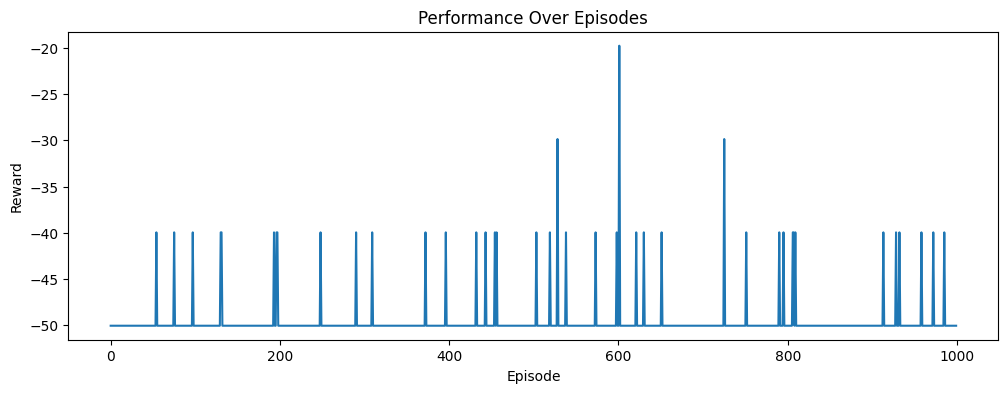

1050


In [1317]:
with open('trained_q_table.pkl', 'rb') as f:
    Q_1 = pickle.load(f)
pose_df = pd.DataFrame(columns=['Initial_Robot_Pose', 'Initial_Target_Pose','step_to_target'])
steps=[]
test_rewards_q_learning = []
epsilon=0.0
for ep in range(1000):
    total_reward = 0
    [x, y, theta], target_pos, episode, step = new_episode(ep)
    step_count = 0
    step_to_target=0

    while True:
        state = get_state(x, y, theta, target_pos)
        action = max(available_actions, key=lambda a: Q.get((state, a), 0))
       
        omega_0,omega_1,omega_2=execute_action(action)    
        
        
        x,y,theta=update_pose(x, y, theta, omega_0, omega_1, omega_2)
        
        
        distance_to_target = math.sqrt((x - target_pos[0])**2 + (y - target_pos[1])**2)
        #print(distance_to_target)
        #robot_pose=[x,y,theta]
        reward = 0
    
        if distance_to_target <= ROBOT_RADIUS:
            #step_to_target+=1
            
            [x,y,theta], target_pos, episode, step = new_episode(ep)
            reward += 10
            
        
        
        #elif state == 1 and action==5:
            #reward += 1
        #elif state == 2 and action==3:
            #reward += 1
        #elif state == 3 and action==10:
            #reward += 1
        #elif state == 4 and action==2:
            #reward += 1
        
        elif distance_to_target >= ROBOT_RADIUS:
            step_to_target += 1
        elif not FIELD.collidepoint(x, y):
            #step_to_target +=1
            
            [x,y,theta], target_pos, episode, step = new_episode(ep)
            reward-=0.01
            
        
        reward -=(step_to_target*0.0001)
        
        total_reward+=reward
        
        
        step_count += 1
        
     
        
        if step_count >= max_steps_per_episode:
            break
    pose_df = pose_df.append({'step_to_target': step_to_target, 'Initial_Robot_Pose':[x,y,theta], 'Initial_Target_Pose':target_pos}, ignore_index=True)

    test_rewards_q_learning.append(total_reward)
    steps.append(step_to_target)

test_avg_q_learning = np.mean(test_rewards_q_learning)
test_std_q_learning = np.std(test_rewards_q_learning)

print(f"Q-learning Test Average: {test_avg_q_learning}, Standard Deviation: {test_std_q_learning}")

# Plotting the rewards
plt.figure(figsize=(12,4))
plt.plot(test_rewards_q_learning)
plt.xlabel('Episode')
plt.ylabel('Reward')
plt.title('Performance Over Episodes')
plt.show()
print(len(rewards))




In [ ]:
pose_df.head(3)





Converting the columns in our dataframe into appropriate data types.

In [1318]:

pose_df['Initial_Robot_Pose'] = pose_df['Initial_Robot_Pose'].astype(str)
pose_df['Initial_Target_Pose'] = pose_df['Initial_Target_Pose'].astype(str)


pose_df[['x_r', 'y_r', 'theta']] = pose_df['Initial_Robot_Pose'].str.strip('[]').str.split(', ', expand=True)


pose_df[['x_r', 'y_r', 'theta']] = pose_df[['x_r', 'y_r', 'theta']].astype(float)




pose_df[['x_t', 'y_t']] = pose_df['Initial_Target_Pose'].str.strip('[]').str.split(', ', expand=True)


pose_df[['x_t', 'y_t']] = pose_df[['x_t', 'y_t']].astype(int)

pose_df.drop(['Initial_Target_Pose','Initial_Robot_Pose'],axis=1,inplace=True)
pose_df[['step_to_target']] = pose_df[['step_to_target']].astype(int)

## Question 2

splitting our dataset into. training and testing set

In [1319]:
from sklearn.model_selection import train_test_split


X = pose_df[['x_r', 'y_r', 'theta','x_t', 'y_t']]
y = pose_df['step_to_target']



In [1320]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)


In [1321]:
y_train.head()

24     1000
467    1000
539    1000
531    1000
618    1000
Name: step_to_target, dtype: int64

In [1322]:
print(pose_df['step_to_target'].mean())
print(pose_df['step_to_target'].std())
print(pose_df['step_to_target'].var())

999.956
0.22828954447393526
0.05211611611611686


Initiating our neural network, it has two hidden layers with a ReLU activation function.It has 64 nodes in each of the hidden layes and the input dimension is the number of predicting variables we have.We train and validate for an Adam optimiser for lr vales 0.01 to 0.001

In [1323]:
import torch
import torch.nn as nn

class RegressionModel(nn.Module):
    def __init__(self, input_dim):
        super(RegressionModel, self).__init__()
        self.fc1 = nn.Linear(input_dim, 64) 
        self.relu = nn.ReLU()                
        self.fc2 = nn.Linear(64, 1)        

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x



In [1324]:
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error,r2_score
import numpy as np
results_df = pd.DataFrame(columns=['Learning Rate', 'Mean MAE', 'Mean MSE', 'Mean R2'])
learning_rates = np.linspace(0.1, 0.01, 10)
for learning_rate in learning_rates:
    num_splits = 5
    kf = KFold(n_splits=num_splits, shuffle=True, random_state=42)
    input_dim = X.shape[1] 
    mae_scores = []
    mse_scores = []
    r2_scores = []
    train_losses=[]
    val_losses = []
    for train_index, val_index in kf.split(X_test):
        X_fold_train, X_fold_val = X.values[train_index], X.values[val_index]
        y_fold_train, y_fold_val = y.values[train_index], y.values[val_index]
        X_fold_train_tensor = torch.tensor(X_fold_train, dtype=torch.float32)
        y_fold_train_tensor = torch.tensor(y_fold_train, dtype=torch.float32)
        X_fold_val_tensor = torch.tensor(X_fold_val, dtype=torch.float32)
        y_fold_val_tensor = torch.tensor(y_fold_val, dtype=torch.float32)
        model1 = RegressionModel(input_dim)
    
    
        criterion = nn.MSELoss()
        optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    
    
    num_epochs = 100
    for epoch in range(num_epochs):
        
        outputs = model(X_fold_train_tensor)
        loss = criterion(outputs, y_fold_train_tensor)
        
        

       
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    
    model1.eval()
    with torch.no_grad():
        y_pred = model(X_fold_val_tensor)
        val_loss = criterion(y_pred, y_fold_val_tensor)
        

   
    fold_mae = mean_absolute_error(y_fold_val, y_pred)
    fold_mse = mean_squared_error(y_fold_val, y_pred)
    fold_r2 = r2_score(y_fold_val, y_pred)
  

   
    mae_scores.append(fold_mae)
    mse_scores.append(fold_mse)
    r2_scores.append(fold_r2)
    train_losses.append(loss.item())
    val_losses.append(val_loss.item())


    mean_mae = np.mean(mae_scores)
    std_mae = np.std(mae_scores)
    mean_mse = np.mean(mse_scores)
    std_mse = np.std(mse_scores)
    mean_r2 = np.mean(r2_scores)
    std_r2 = np.std(r2_scores)
    
    results_df = results_df.append({'Learning Rate': learning_rate,
                                    'Mean MAE': mean_mae,
                                    'Mean MSE': mean_mse,
                                    'Mean R2': mean_r2},
                                   ignore_index=True)
    
    
    


    #print(f"Mean MAE: {mean_mae},  lr:{learning_rate}")
    #print(f"Mean MSE: {mean_mse}")
    #print(f"Mean R2: {mean_r2}")

       
        

/opt/homebrew/anaconda3/lib/python3.10/site-packages/torch/nn/modules/loss.py:536: UserWarning: Using a target size (torch.Size([320])) that is different to the input size (torch.Size([320, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/opt/homebrew/anaconda3/lib/python3.10/site-packages/torch/nn/modules/loss.py:536: UserWarning: Using a target size (torch.Size([80])) that is different to the input size (torch.Size([80, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/var/folders/5y/466mqc5d1c9722h6thyb41hr0000gn/T/ipykernel_21683/1439310704.py:71: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  results_df = results_df.append({'Learning Rate': learning_rate,


In [ ]:
print(results_df)

Training and validation for SGD. optimiser with learning rate range 0.01 to 0.001

In [1325]:
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error,r2_score
import numpy as np
results_df = pd.DataFrame(columns=['Learning Rate', 'Mean MAE', 'Mean MSE', 'Mean R2'])
learning_rates = np.linspace(0.1, 0.01, 10)
for learning_rate in learning_rates:
    num_splits = 5
    kf = KFold(n_splits=num_splits, shuffle=True, random_state=42)
    input_dim = X.shape[1] 
    mae_scores = []
    mse_scores = []
    r2_scores = []
    train_losses=[]
    val_losses = []
    for train_index, val_index in kf.split(X_test):
        X_fold_train, X_fold_val = X.values[train_index], X.values[val_index]
        y_fold_train, y_fold_val = y.values[train_index], y.values[val_index]
        X_fold_train_tensor = torch.tensor(X_fold_train, dtype=torch.float32)
        y_fold_train_tensor = torch.tensor(y_fold_train, dtype=torch.float32)
        X_fold_val_tensor = torch.tensor(X_fold_val, dtype=torch.float32)
        y_fold_val_tensor = torch.tensor(y_fold_val, dtype=torch.float32)
        model2 = RegressionModel(input_dim)
    
    
        criterion = nn.MSELoss()
        optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
    
    
    num_epochs = 100
    for epoch in range(num_epochs):
       
        outputs = model(X_fold_train_tensor)
        loss = criterion(outputs, y_fold_train_tensor)
        
        

       
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    
    model2.eval()
    with torch.no_grad():
        y_pred = model(X_fold_val_tensor)
        val_loss = criterion(y_pred, y_fold_val_tensor)
       

   
    fold_mae = mean_absolute_error(y_fold_val, y_pred)
    fold_mse = mean_squared_error(y_fold_val, y_pred)
    fold_r2 = r2_score(y_fold_val, y_pred)
  

   
    mae_scores.append(fold_mae)
    mse_scores.append(fold_mse)
    r2_scores.append(fold_r2)
    train_losses.append(loss.item())
    val_losses.append(val_loss.item())


    mean_mae = np.mean(mae_scores)
    std_mae = np.std(mae_scores)
    mean_mse = np.mean(mse_scores)
    std_mse = np.std(mse_scores)
    mean_r2 = np.mean(r2_scores)
    std_r2 = np.std(r2_scores)
    
    results_df = results_df.append({'Learning Rate': learning_rate,
                                    'Mean MAE': mean_mae,
                                    'Mean MSE': mean_mse,
                                    'Mean R2': mean_r2},
                                   ignore_index=True)
    
    
    


    #print(f"Mean MAE: {mean_mae},  lr:{learning_rate}")
    #print(f"Mean MSE: {mean_mse}")
    #print(f"Mean R2: {mean_r2}")

       
        

/opt/homebrew/anaconda3/lib/python3.10/site-packages/torch/nn/modules/loss.py:536: UserWarning: Using a target size (torch.Size([320])) that is different to the input size (torch.Size([320, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/opt/homebrew/anaconda3/lib/python3.10/site-packages/torch/nn/modules/loss.py:536: UserWarning: Using a target size (torch.Size([80])) that is different to the input size (torch.Size([80, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/var/folders/5y/466mqc5d1c9722h6thyb41hr0000gn/T/ipykernel_21683/3405823992.py:71: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  results_df = results_df.append({'Learning Rate': learning_rate,


/opt/homebrew/anaconda3/lib/python3.10/site-packages/torch/nn/modules/loss.py:536: UserWarning: Using a target size (torch.Size([80])) that is different to the input size (torch.Size([80, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/var/folders/5y/466mqc5d1c9722h6thyb41hr0000gn/T/ipykernel_21683/3405823992.py:71: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  results_df = results_df.append({'Learning Rate': learning_rate,


In [1326]:
print(results_df)

   Learning Rate  Mean MAE  Mean MSE   Mean R2
0           0.10  0.075433  0.047973 -0.009951
1           0.09  0.075433  0.047973 -0.009951
2           0.08  0.075433  0.047973 -0.009951
3           0.07  0.075433  0.047973 -0.009951
4           0.06  0.075433  0.047973 -0.009951
5           0.05  0.075433  0.047973 -0.009951
6           0.04  0.075433  0.047973 -0.009951
7           0.03  0.075433  0.047973 -0.009951
8           0.02  0.075433  0.047973 -0.009951
9           0.01  0.075433  0.047973 -0.009951


In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, 5 + 1), train_losses, label='Training Loss')
plt.plot(range(1, 5 + 1), val_losses, label='validation losses')
plt.xlabel('Fold')
plt.ylabel('Loss')
plt.title('Training Curve')
plt.legend()
plt.grid(True)
plt.show()






Testing the performance on our testing data.

In [1327]:

X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32)


model1.eval()


with torch.no_grad():
    y_pred = model(X_test_tensor)

mae = mean_absolute_error(y_test_tensor, y_pred)
mse = mean_squared_error(y_test_tensor, y_pred)
r2 = r2_score(y_test_tensor, y_pred)


print(f"MAE on testing data: {mae}")
print(f"MSE on testing data: {mse}")
print(f"R2 on testing data: {r2}")


MAE on testing data: 0.06642242521047592
MSE on testing data: 0.05853784456849098
R2 on testing data: -0.002360323481846116
